# RiceLeafDiseaseBD Dataset — KD + FP16 QAT Pipeline — 5-Fold Cross Validation
## ViT-B/16 Teacher → EfficientNet-B0 Student → FP16 QAT  |  StratifiedKFold (k=5)
**Dataset:** RiceLeafDiseaseBD (Mendeley, v2) — field images, 6 classes
**Classes:** Blast, Brown spot, Healthy, Leaf smut, Rice Tungro, Sheath blight


In [ ]:
# ── CELL 1 ───────────────────────────────────────────────────────
import os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DATA_DIR = "/content/drive/MyDrive/Research/RiceLeafDiseaseDataset/Original images"

OUTPUT_DIR = "/content/drive/MyDrive/Research/Model_save/RiceLeafDiseaseBD_CV"
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = sorted([
    d for d in os.listdir(DRIVE_DATA_DIR)
    if os.path.isdir(os.path.join(DRIVE_DATA_DIR, d))
])

print(f"Found {len(classes)} classes in Drive:")
for c in classes:
    n = len([
        f for f in os.listdir(os.path.join(DRIVE_DATA_DIR, c))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    print(f"  {c}: {n} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 6 classes in Drive:
  Blast: 1326 images
  Brown spot: 2178 images
  Healthy: 1575 images
  Leaf smut: 725 images
  Rice Tungro: 2244 images
  Sheath blight: 1722 images


In [ ]:
# ── CELL 2: Copy dataset to local SSD ───────────
import shutil, time

LOCAL_DATA = "/content/RiceLeafDiseaseBD"

if not os.path.exists(LOCAL_DATA):
    print("Copying dataset from Drive to local SSD...")
    t0 = time.time()
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA)
    print(f"Done in {(time.time()-t0)/60:.1f} min")
else:
    print("Local copy already exists — skipping copy.")

# Use local path from now on
DATA_DIR = LOCAL_DATA

classes = sorted([d for d in os.listdir(DATA_DIR)
                  if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"\nLocal dataset ready: {len(classes)} classes")

Local copy already exists — skipping copy.

Local dataset ready: 6 classes


In [ ]:
# # ── DEDUPLICATION: Remove near-duplicate images using perceptual hashing ──────
# # Run once per session. Safe to re-run (skips already-cleaned folders).
# # Uses pHash with Hamming distance ≤ 10 to detect burst-shot near-duplicates.

# import os
# import hashlib
# from PIL import Image
# import numpy as np
# from scipy.fft import dct

# def phash(image_path, hash_size=8):
#     """Compute perceptual hash (pHash) for an image."""
#     img = Image.open(image_path).convert("L").resize(
#         (hash_size * 4, hash_size * 4), Image.LANCZOS
#     )
#     pixels = np.array(img, dtype=float)
#     dct_vals = dct(dct(pixels, axis=0), axis=1)
#     dct_low = dct_vals[:hash_size, :hash_size]
#     mean = dct_low.mean()
#     return (dct_low > mean).flatten()

# def hamming(hash1, hash2):
#     return np.count_nonzero(hash1 != hash2)

# THRESHOLD = 10  # Hamming distance ≤ 10 → near-duplicate

# total_removed = 0
# total_kept    = 0

# for class_name in sorted(os.listdir(DATA_DIR)):
#     class_path = os.path.join(DATA_DIR, class_name)
#     if not os.path.isdir(class_path):
#         continue

#     image_files = sorted([
#         os.path.join(class_path, f)
#         for f in os.listdir(class_path)
#         if f.lower().endswith(('.jpg', '.jpeg', '.png'))
#     ])

#     hashes   = []   # (path, phash)
#     to_delete = set()

#     for img_path in image_files:
#         try:
#             h = phash(img_path)
#         except Exception:
#             continue

#         # Compare against all kept images so far
#         duplicate = False
#         for kept_path, kept_h in hashes:
#             if hamming(h, kept_h) <= THRESHOLD:
#                 to_delete.add(img_path)
#                 duplicate = True
#                 break

#         if not duplicate:
#             hashes.append((img_path, h))

#     # Delete duplicates
#     for img_path in to_delete:
#         os.remove(img_path)

#     kept    = len(hashes)
#     removed = len(to_delete)
#     total_kept    += kept
#     total_removed += removed
#     print(f"  {class_name:<20} | kept: {kept:4d} | removed: {removed:4d}")

# print(f"\nDeduplication complete.")
# print(f"  Total kept   : {total_kept}")
# print(f"  Total removed: {total_removed}")
# print(f"  Final dataset: {total_kept} unique images")

In [ ]:
import shutil, os, time

# Wipe damaged local copy
shutil.rmtree("/content/RiceLeafDiseaseBD")
print("Wiped local copy.")

# Re-copy from Drive
DRIVE_DATA_DIR = "/content/drive/MyDrive/Research/RiceLeafDiseaseDataset/Original images"
t0 = time.time()
shutil.copytree(DRIVE_DATA_DIR, "/content/RiceLeafDiseaseBD")
print(f"Done in {(time.time()-t0)/60:.1f} min")

# Verify
total = 0
for c in sorted(os.listdir("/content/RiceLeafDiseaseBD")):
    p = f"/content/RiceLeafDiseaseBD/{c}"
    if os.path.isdir(p):
        n = len([f for f in os.listdir(p)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  {c}: {n}")
        total += n
print(f"Total: {total}")

Wiped local copy.
Done in 1.4 min
  Blast: 1326
  Brown spot: 2178
  Healthy: 1575
  Leaf smut: 725
  Rice Tungro: 2244
  Sheath blight: 1722
Total: 9770


In [ ]:
# ── CELL 3: Imports ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets, models
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix,
                              accuracy_score, classification_report)
from sklearn.model_selection import train_test_split
import numpy as np
import os, csv, copy, json, random, time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import timm
from pathlib import Path
from PIL import Image

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda


In [ ]:
# ── CELL 4: Hyperparameters & Config ─────────────────────────────────────────
CFG = {
    # Data
    "data_dir"   : DATA_DIR,
    "output_dir" : OUTPUT_DIR,
    "img_size"   : 224,
    "batch_size" : 32,
    "num_workers": 4,
    # Splits (stratified)
    "train_frac" : 0.80,
    "val_frac"   : 0.10,
    "test_frac"  : 0.10,
    "random_seed": 42,
    # Teacher training
    "teacher_epochs"  : 100,
    "teacher_base_lr" : 1e-4,
    "teacher_wd"      : 1e-4,
    "teacher_patience": 15,
    "teacher_warmup"  : 5,
    "lr_decay"        : 0.65,
    # Student (KD) training
    "student_epochs"  : 100,
    "student_lr"      : 3e-4,
    "student_wd"      : 1e-4,
    "student_patience": 15,
    # KD
    "kd_alpha"   : 0.4,
    "kd_T"       : 4.0,
    "mixup_alpha": 0.4,
    # Label smoothing
    "label_smoothing": 0.1,
    # QAT fine-tuning
    "qat_epochs"  : 30,
    "qat_lr"      : 1e-5,
    "qat_wd"      : 0.01,
    "qat_patience": 12,
}
print("Config loaded.")
print(f"  Classes will be detected automatically from {DATA_DIR}")


Config loaded.
  Classes will be detected automatically from /content/RiceLeafDiseaseBD


In [ ]:
# ── CELL 5: Transforms ────────────────────────────────────────────────────────
# Exact V7 (potato) augmentation profile — proven for field-based uncontrolled images.

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Transforms defined.")
print("  Train: RandomResizedCrop(0.6-1.0) + Flips + Rot30 + ColorJitter(0.4) + GaussianBlur + RandomErasing(0.25)")
print("  Val/Test: Resize(224) + CenterCrop + Normalize")


Transforms defined.
  Train: RandomResizedCrop(0.6-1.0) + Flips + Rot30 + ColorJitter(0.4) + GaussianBlur + RandomErasing(0.25)
  Val/Test: Resize(224) + CenterCrop + Normalize


In [ ]:
# ── CELL 6: SafeImageFolder + Dataset Split ───────────────────────────────────
class SafeImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        self.invalid_files = []

    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            sample = self.loader(path)
            if self.transform is not None:
                sample = self.transform(sample)
            return sample, target
        except Exception:
            self.invalid_files.append(path)
            dummy = self.transform(Image.new('RGB', (224, 224))) if self.transform else torch.zeros(3, 224, 224)
            return dummy, -1


# Load full dataset
full_dataset = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)
class_names  = full_dataset.classes
num_classes  = len(class_names)
print(f"Total images : {len(full_dataset)}")
print(f"Num classes  : {num_classes}")

# Stratified split: 80 / 10 / 10
all_indices = list(range(len(full_dataset)))
all_targets = [full_dataset.samples[i][1] for i in all_indices]

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.20,
    stratify=all_targets, random_state=CFG["random_seed"]
)
temp_targets = [all_targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=temp_targets, random_state=CFG["random_seed"]
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

from collections import Counter
train_dist = Counter([all_targets[i] for i in train_idx])
val_dist   = Counter([all_targets[i] for i in val_idx])
test_dist  = Counter([all_targets[i] for i in test_idx])
print("\nClass distribution check (first 5 classes):")
for cls_idx, cls_name in enumerate(class_names[:5]):
    print(f"  {cls_name}: train={train_dist[cls_idx]}, val={val_dist[cls_idx]}, test={test_dist[cls_idx]}")

Total images : 9770
Num classes  : 6
Train: 7816 | Val: 977 | Test: 977

Class distribution check (first 5 classes):
  Blast: train=1061, val=132, test=133
  Brown spot: train=1742, val=218, test=218
  Healthy: train=1260, val=158, test=157
  Leaf smut: train=580, val=72, test=73
  Rice Tungro: train=1795, val=225, test=224


In [ ]:
# ── CELL 7: DataLoaders ───────────────────────────────────────────────────────
train_data = SafeImageFolder(CFG["data_dir"], transform=train_transform)
val_data   = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)
test_data  = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)

train_loader = DataLoader(Subset(train_data, train_idx),
                          batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(Subset(val_data, val_idx),
                          batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(Subset(test_data, test_idx),
                          batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          persistent_workers=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Class-weighted CE loss (computed from TRAIN split only)
train_labels  = [all_targets[i] for i in train_idx]
class_counts  = torch.zeros(num_classes)
for lbl in train_labels:
    class_counts[lbl] += 1
class_weights = len(train_labels) / (num_classes * class_counts.clamp(min=1))
class_weights = class_weights.to(device)
print("Class weights computed (min/max):", f"{class_weights.min():.3f} / {class_weights.max():.3f}")

Train batches: 245
Val   batches: 31
Test  batches: 31
Class weights computed (min/max): 0.726 / 2.246


In [ ]:
# ── CELL 7b: Dataset Validation ───────────────────────────────────────────────
# Mirrors validate_dataset() from V7 exactly.
# Checks directory existence, image count per class, and file integrity.

def validate_dataset(data_dir, class_names):
    print("Validating dataset...")
    total_images = 0
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Directory {data_dir} does not exist")
    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if not os.path.exists(class_path):
            print(f"  WARNING: Class directory missing — {class_path}")
            continue
        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"  {class_name}: {len(files)} images")
        total_images += len(files)
        for fname in files:
            fpath = os.path.join(class_path, fname)
            if not os.path.isfile(fpath):
                print(f"  ERROR: Inaccessible — {fpath}")
            try:
                Image.open(fpath).verify()
            except Exception as e:
                print(f"  ERROR: Corrupted image — {fpath}: {e}")
    if total_images == 0:
        raise ValueError("No valid images found in dataset")
    print(f"Validation complete: {total_images} images across {len(class_names)} classes.")

validate_dataset(CFG["data_dir"], class_names)

Validating dataset...
  Blast: 1326 images
  Brown spot: 2178 images
  Healthy: 1575 images
  Leaf smut: 725 images
  Rice Tungro: 2244 images
  Sheath blight: 1722 images
Validation complete: 9770 images across 6 classes.


In [ ]:
# ── CELL 8: Model Definitions & Utilities ─────────────────────────────────────

class StudentNet(nn.Module):
    """
    EfficientNet-B0 student.
    feature_adapter projects 1280-d → 768-d teacher space.
    Used only during KD training; stripped at deployment.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_ch = self.base.classifier[1].in_features   # 1280
        self.base.classifier[1] = nn.Linear(in_ch, num_classes)
        self.feature_adapter = nn.Linear(1280, 768)

    def forward(self, x, return_features=False):
        features = self.base.features(x)
        features = self.base.avgpool(features)
        features = torch.flatten(features, 1)
        logits   = self.base.classifier(features)
        if return_features:
            return logits, features
        return logits


def get_layer_wise_params(model, base_lr=1e-4, decay=0.65):
    """Layer-wise LR decay for ViT: head → blocks → patch_embed."""
    param_groups = []
    param_groups.append({"params": model.head.parameters(), "lr": base_lr})
    blocks = list(model.blocks)
    for i, block in enumerate(reversed(blocks)):
        layer_lr = base_lr * (decay ** (i + 1))
        param_groups.append({"params": block.parameters(), "lr": layer_lr})
    param_groups.append({
        "params": model.patch_embed.parameters(),
        "lr": base_lr * (decay ** (len(blocks) + 1))
    })
    return param_groups


print("StudentNet and layer-wise LR utility defined.")

StudentNet and layer-wise LR utility defined.


In [ ]:
# ── CELL 9: EarlyStopping + MixUp + save_clean_student ───────────────────────

class EarlyStopping:
    def __init__(self, patience=10, delta=0.001, verbose=True, path='checkpoint.pt'):
        self.patience   = patience
        self.delta      = delta
        self.verbose    = verbose
        self.path       = path
        self.best_score = None
        self.early_stop = False
        self.counter    = 0
        self.best_f1    = 0.0

    def __call__(self, val_f1, model):
        if self.best_score is None:
            self.best_score = val_f1
            self._save(val_f1, model)
        elif val_f1 < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'  EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_f1
            self._save(val_f1, model)
            self.counter = 0

    def _save(self, val_f1, model):
        if self.verbose:
            print(f'  Val F1 improved ({self.best_f1:.4f} → {val_f1:.4f}). Saving model.')
        torch.save(model.state_dict(), self.path)
        self.best_f1 = val_f1


def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def save_clean_student(student_model, save_path_fp32, save_path_fp16, num_classes, device):
    """Strips training-only feature_adapter before saving for deployment."""
    clean = models.efficientnet_b0(weights=None)
    clean.classifier[1] = nn.Linear(clean.classifier[1].in_features, num_classes)
    student_state = {k: v.cpu() for k, v in student_model.state_dict().items()}
    clean_state   = {k[len('base.'):]: v
                     for k, v in student_state.items() if k.startswith('base.')}
    clean.load_state_dict(clean_state)
    clean = clean.to(device).eval()

    torch.save(clean.state_dict(), save_path_fp32)
    fp32_mb = sum(p.numel() for p in clean.parameters()) * 4 / 1024**2
    print(f"  [Clean FP32] → {save_path_fp32}  ({fp32_mb:.2f} MB)")

    clean_fp16 = None
    if save_path_fp16 is not None:
        clean_fp16 = copy.deepcopy(clean).half()
        torch.save(clean_fp16.state_dict(), save_path_fp16)
        fp16_mb = sum(p.numel() for p in clean_fp16.parameters()) * 2 / 1024**2
        print(f"  [Clean FP16] → {save_path_fp16}  ({fp16_mb:.2f} MB)")
    return clean, clean_fp16


print("Helpers defined.")

Helpers defined.


In [ ]:
# ── CELL 10: Plot Helpers ─────────────────────────────────────────────────────

def plot_metrics(train_losses, val_losses, train_accs, val_accs,
                 train_precisions, train_recalls, train_f1s,
                 val_precisions, val_recalls, val_f1s,
                 val_labels, val_preds, variant, output_dir):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses,   'r-', label='Val Loss')
    plt.title(f'Loss — {variant}'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'loss_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_accs, 'b-', label='Train Acc')
    plt.plot(epochs, val_accs,   'r-', label='Val Acc')
    plt.title(f'Accuracy — {variant}'); plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'accuracy_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, val_precisions, 'b-', label='Val Precision')
    plt.plot(epochs, val_recalls,    'r-', label='Val Recall')
    plt.plot(epochs, val_f1s,        'g-', label='Val F1')
    plt.title(f'Val P/R/F1 — {variant}'); plt.xlabel('Epoch'); plt.ylabel('Score')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'prf1_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    cm = confusion_matrix(val_labels, val_preds)
    fig_size = max(12, num_classes // 2)
    plt.figure(figsize=(fig_size, fig_size - 2))
    sns.heatmap(cm, annot=(num_classes <= 20), fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 7})
    plt.title(f'Confusion Matrix — {variant}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'confusion_matrix_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


def plot_qat_metrics(train_losses, val_losses, train_accs, val_accs, variant, output_dir):
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, train_losses, 'b-', label='Train Loss')
    axes[0].plot(epochs, val_losses,   'r-', label='Val Loss')
    axes[0].set_title(f'QAT Loss — {variant}'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(epochs, train_accs, 'b-', label='Train Acc')
    axes[1].plot(epochs, val_accs,   'r-', label='Val Acc')
    axes[1].set_title(f'QAT Accuracy — {variant}'); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'qat_metrics_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


def plot_final_comparison(teacher_metrics, student_metrics, qat_metrics, output_dir):
    metric_names = ["Accuracy", "Precision", "Recall", "F1"]
    teacher_vals = [teacher_metrics[m] for m in metric_names]
    student_vals = [student_metrics[m] for m in metric_names]
    qat_vals     = [qat_metrics[m]     for m in metric_names]

    x     = np.arange(len(metric_names))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, teacher_vals, width, label='Teacher (ViT-B/16)',   color='steelblue')
    plt.bar(x,         student_vals, width, label='Student FP32 (EffB0)', color='darkorange')
    plt.bar(x + width, qat_vals,     width, label='QAT Student FP16',     color='seagreen')
    plt.xticks(x, metric_names)
    plt.ylabel('Score'); plt.ylim(0, 1.05)
    plt.title('RiceLeafDiseaseBD — Test-Set Performance: Teacher vs Student vs QAT')
    plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'final_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print("Saved final_comparison.png")


print("Plot helpers defined.")

Plot helpers defined.


In [ ]:
# ── CELL 11: evaluate_on_loader ───────────────────────────────────────────────
def evaluate_on_loader(model, loader, device, use_half=False):
    model.eval()
    if use_half:
        model = model.half()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            images = images[valid_mask].to(device)
            labels = labels[valid_mask].to(device)
            if use_half:
                images = images.half()
            outputs = model(images)
            preds   = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)
    return acc, prec, rec, f1, all_preds, all_labels


print("evaluate_on_loader defined.")

evaluate_on_loader defined.


In [ ]:
# ── CELL 12: train_teacher ────────────────────────────────────────────────────
def train_teacher(model, train_loader, val_loader, criterion, optimizer,
                  scheduler, num_epochs, device, early_stopping, output_dir):
    model.to(device)
    (train_losses, val_losses, train_accs, val_accs,
     train_precisions, train_recalls, train_f1s,
     val_precisions, val_recalls, val_f1s) = [[] for _ in range(10)]
    epoch_summaries = []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []

        for images, labels in tqdm(train_loader,
                                   desc=f"Teacher Epoch {epoch+1}/{num_epochs}", leave=False):
            valid_mask = labels != -1
            if not valid_mask.any(): continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            images, y_a, y_b, lam = mixup_data(images, labels, CFG["mixup_alpha"])

            optimizer.zero_grad()
            outputs = model(images)
            loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        t_loss = running_loss / max(total, 1)
        t_acc  = 100 * correct / max(total, 1)
        t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted', zero_division=0)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        v_preds, v_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any(): continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                v_loss  += loss.item() * images.size(0)
                _, pred   = torch.max(outputs, 1)
                v_total  += labels.size(0)
                v_correct+= (pred == labels).sum().item()
                v_preds.extend(pred.cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        v_loss /= max(v_total, 1)
        v_acc   = 100 * v_correct / max(v_total, 1)
        v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
            v_labels, v_preds, average='weighted', zero_division=0)

        train_losses.append(t_loss);  val_losses.append(v_loss)
        train_accs.append(t_acc);     val_accs.append(v_acc)
        train_precisions.append(t_prec); val_precisions.append(v_prec)
        train_recalls.append(t_rec);    val_recalls.append(v_rec)
        train_f1s.append(t_f1);        val_f1s.append(v_f1)

        epoch_summaries.append({
            'epoch': epoch+1, 'train_loss': t_loss, 'train_accuracy': t_acc,
            'train_precision': t_prec, 'train_recall': t_rec, 'train_f1': t_f1,
            'val_loss': v_loss, 'val_accuracy': v_acc,
            'val_precision': v_prec, 'val_recall': v_rec, 'val_f1': v_f1
        })
        print(f"[Teacher] Epoch {epoch+1:3d} | "
              f"T-Loss:{t_loss:.4f} T-Acc:{t_acc:.2f}% | "
              f"V-Loss:{v_loss:.4f} V-Acc:{v_acc:.2f}% V-F1:{v_f1:.4f} | "
              f"LR:{optimizer.param_groups[0]['lr']:.2e}")

        early_stopping(v_f1, model)
        if early_stopping.early_stop:
            print("Early stopping triggered (Teacher).")
            break
        scheduler.step()

    pd.DataFrame(epoch_summaries).to_csv(
        os.path.join(output_dir, 'epoch_summary_teacher.csv'), index=False)
    model.load_state_dict(torch.load(early_stopping.path, weights_only=True))
    plot_metrics(train_losses, val_losses, train_accs, val_accs,
                 train_precisions, train_recalls, train_f1s,
                 val_precisions, val_recalls, val_f1s,
                 v_labels, v_preds, "teacher", output_dir)
    return model


print("train_teacher defined.")

train_teacher defined.


In [ ]:
# ── CELL 13: train_student ────────────────────────────────────────────────────
def train_student(model, teacher_model, train_loader, val_loader,
                  criterion, optimizer, scheduler, num_epochs,
                  device, early_stopping, output_dir):
    model.to(device)
    teacher_model.to(device).eval()

    alpha, T = CFG["kd_alpha"], CFG["kd_T"]

    (train_losses, val_losses, train_accs, val_accs,
     train_precisions, train_recalls, train_f1s,
     val_precisions, val_recalls, val_f1s) = [[] for _ in range(10)]
    epoch_summaries = []

    for epoch in tqdm(range(num_epochs), desc="Student Epochs"):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []

        for images, labels in train_loader:
            valid_mask = labels != -1
            if not valid_mask.any(): continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            with torch.no_grad():
                teacher_outputs = teacher_model(images)

            mixed_images, y_a, y_b, lam = mixup_data(images, labels, CFG["mixup_alpha"])
            outputs  = model(mixed_images, return_features=False)

            kd_loss  = F.kl_div(F.log_softmax(outputs / T, dim=1),
                                 F.softmax(teacher_outputs / T, dim=1),
                                 reduction='batchmean') * (T * T)
            ce_loss  = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            loss     = alpha * kd_loss + (1 - alpha) * ce_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        t_loss = running_loss / max(total, 1)
        t_acc  = 100 * correct / max(total, 1)
        t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted', zero_division=0)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        v_preds, v_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any(): continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                v_loss  += loss.item() * images.size(0)
                _, pred   = torch.max(outputs, 1)
                v_total  += labels.size(0)
                v_correct+= (pred == labels).sum().item()
                v_preds.extend(pred.cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        v_loss /= max(v_total, 1)
        v_acc   = 100 * v_correct / max(v_total, 1)
        v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
            v_labels, v_preds, average='weighted', zero_division=0)

        train_losses.append(t_loss);  val_losses.append(v_loss)
        train_accs.append(t_acc);     val_accs.append(v_acc)
        train_precisions.append(t_prec); val_precisions.append(v_prec)
        train_recalls.append(t_rec);    val_recalls.append(v_rec)
        train_f1s.append(t_f1);        val_f1s.append(v_f1)
        epoch_summaries.append({
            'epoch': epoch+1, 'train_loss': t_loss, 'train_accuracy': t_acc,
            'train_precision': t_prec, 'train_recall': t_rec, 'train_f1': t_f1,
            'val_loss': v_loss, 'val_accuracy': v_acc,
            'val_precision': v_prec, 'val_recall': v_rec, 'val_f1': v_f1
        })
        print(f"[Student] Epoch {epoch+1:3d} | "
              f"T-Loss:{t_loss:.4f} T-Acc:{t_acc:.2f}% | "
              f"V-Loss:{v_loss:.4f} V-Acc:{v_acc:.2f}% V-F1:{v_f1:.4f}")

        early_stopping(v_f1, model)
        if early_stopping.early_stop:
            print("Early stopping triggered (Student).")
            break
        scheduler.step()

    pd.DataFrame(epoch_summaries).to_csv(
        os.path.join(output_dir, 'epoch_summary_student.csv'), index=False)
    model.load_state_dict(torch.load(early_stopping.path, weights_only=True))
    plot_metrics(train_losses, val_losses, train_accs, val_accs,
                 train_precisions, train_recalls, train_f1s,
                 val_precisions, val_recalls, val_f1s,
                 v_labels, v_preds, "student", output_dir)
    return model, (train_losses, val_losses, train_accs, val_accs,
                   train_precisions, train_recalls, train_f1s,
                   val_precisions, val_recalls, val_f1s,
                   v_labels, v_preds)


print("train_student defined.")

train_student defined.


In [ ]:
# ── CELL 14: train_qat_student ────────────────────────────────────────────────
def train_qat_student(student_ckpt_path, teacher_model, train_loader, val_loader,
                      device, num_classes, output_dir,
                      num_epochs=30, lr=1e-5, weight_decay=0.01, patience=12):
    alpha, T = CFG["kd_alpha"], CFG["kd_T"]

    model_qat = StudentNet(num_classes=num_classes).to(device)
    model_qat.load_state_dict(torch.load(student_ckpt_path, map_location=device))
    model_qat.eval()
    model_qat = copy.deepcopy(model_qat).to(device)

    optimizer = torch.optim.AdamW(model_qat.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

    best_val_acc = 0.0
    patience_ctr = 0
    best_path    = os.path.join(output_dir, "qat_student_best.pth")

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(num_epochs):
        model_qat.train()
        t_loss, seen, t_correct, t_total = 0.0, 0, 0, 0

        for images, labels in train_loader:
            valid_mask = labels != -1
            if not valid_mask.any(): continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            with torch.no_grad():
                teacher_logits = teacher_model(images)

            mixed_images, y_a, y_b, lam = mixup_data(images, labels, CFG["mixup_alpha"])

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                student_logits = model_qat(mixed_images, return_features=False)
                kd_loss = F.kl_div(F.log_softmax(student_logits / T, dim=1),
                                   F.softmax(teacher_logits  / T, dim=1),
                                   reduction='batchmean') * (T * T)
                ce_loss = lam * criterion(student_logits, y_a) + (1 - lam) * criterion(student_logits, y_b)
                loss    = alpha * kd_loss + (1 - alpha) * ce_loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            t_loss   += loss.item() * images.size(0)
            seen     += images.size(0)
            preds     = student_logits.argmax(1)
            t_correct+= (preds == labels).sum().item()
            t_total  += labels.size(0)

        t_loss /= max(seen, 1)
        t_acc   = 100.0 * t_correct / max(t_total, 1)

        model_qat.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any(): continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    t_logits = teacher_model(images)
                    s_logits = model_qat(images, return_features=False)
                    kd_loss  = F.kl_div(F.log_softmax(s_logits / T, dim=1),
                                        F.softmax(t_logits / T, dim=1),
                                        reduction='batchmean') * (T * T)
                    ce_loss  = criterion(s_logits, labels)
                    vloss    = alpha * kd_loss + (1 - alpha) * ce_loss
                v_loss   += vloss.item() * images.size(0)
                preds     = s_logits.argmax(1)
                v_correct+= (preds == labels).sum().item()
                v_total  += labels.size(0)

        v_loss /= max(v_total, 1)
        v_acc   = 100.0 * v_correct / max(v_total, 1)

        train_losses.append(t_loss); val_losses.append(v_loss)
        train_accs.append(t_acc);   val_accs.append(v_acc)

        print(f"[QAT] Epoch {epoch+1:3d} | "
              f"T-Loss:{t_loss:.4f} T-Acc:{t_acc:.2f}% | "
              f"V-Loss:{v_loss:.4f} V-Acc:{v_acc:.2f}%")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            patience_ctr = 0
            torch.save(model_qat.state_dict(), best_path)
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print("QAT early stopping triggered.")
                break
        scheduler.step()

    best_model = StudentNet(num_classes=num_classes).to(device)
    best_model.load_state_dict(torch.load(best_path, map_location=device))
    best_model.eval()
    fp16_model = copy.deepcopy(best_model).half()

    save_clean_student(
        best_model,
        save_path_fp32=os.path.join(output_dir, "qat_clean_fp32.pt"),
        save_path_fp16=os.path.join(output_dir, "qat_clean_fp16.pt"),
        num_classes=num_classes, device=device
    )
    plot_qat_metrics(train_losses, val_losses, train_accs, val_accs,
                     "qat_student", output_dir)
    return best_model, fp16_model, best_path, (train_losses, val_losses, train_accs, val_accs)


print("train_qat_student defined.")

train_qat_student defined.



FOLD 1/5  |  train=7816  val=1954
Class weights (min/max): 0.726 / 2.246

[Fold 1] Training Teacher...


[Teacher] Epoch   1 | T-Loss:1.6188 T-Acc:27.58% | V-Loss:1.2657 V-Acc:61.31% V-F1:0.6014 | LR:1.00e-05
  Val F1 improved (0.0000 → 0.6014). Saving model.


[Teacher] Epoch   2 | T-Loss:1.4089 T-Acc:43.96% | V-Loss:1.0439 V-Acc:73.90% V-F1:0.7457 | LR:2.80e-05
  Val F1 improved (0.6014 → 0.7457). Saving model.


[Teacher] Epoch   3 | T-Loss:1.2929 T-Acc:45.98% | V-Loss:0.9465 V-Acc:80.40% V-F1:0.8062 | LR:4.60e-05
  Val F1 improved (0.7457 → 0.8062). Saving model.


[Teacher] Epoch   4 | T-Loss:1.2453 T-Acc:45.74% | V-Loss:1.0011 V-Acc:75.59% V-F1:0.7685 | LR:6.40e-05
  EarlyStopping: 1/15


...

[Teacher] Epoch  25 | T-Loss:0.8813 T-Acc:57.84% | V-Loss:0.7444 V-Acc:89.71% V-F1:0.8968 | LR:9.05e-05
  EarlyStopping: 11/15


[Teacher] Epoch  26 | T-Loss:0.8868 T-Acc:56.00% | V-Loss:0.7447 V-Acc:89.82% V-F1:0.8981 | LR:8.96e-05
  EarlyStopping: 12/15


[Teacher] Epoch  27 | T-Loss:0.8849 T-Acc:54.43% | V-Loss:0.7402 V-Acc:90.07% V-F1:0.9004 | LR:8.85e-05
  EarlyStopping: 13/15


[Teacher] Epoch  28 | T-Loss:0.8614 T-Acc:58.50% | V-Loss:0.7414 V-Acc:89.97% V-F1:0.8989 | LR:8.75e-05
  EarlyStopping: 14/15


[Teacher] Epoch  29 | T-Loss:0.8496 T-Acc:59.44% | V-Loss:0.7471 V-Acc:89.30% V-F1:0.8940 | LR:8.64e-05
  EarlyStopping: 15/15
Early stopping triggered (Teacher).


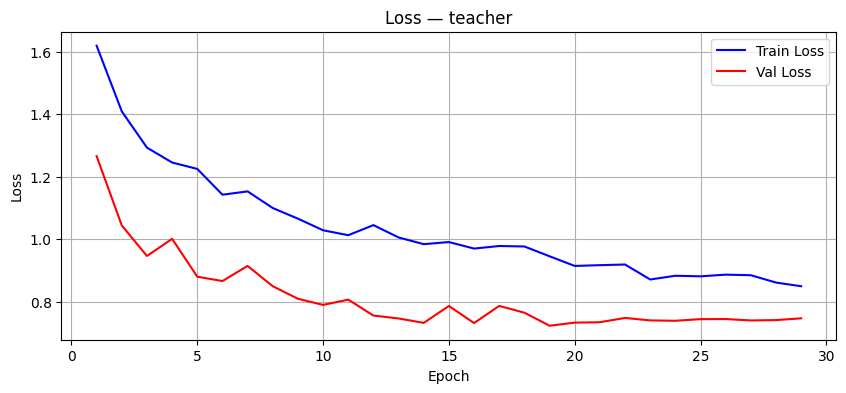

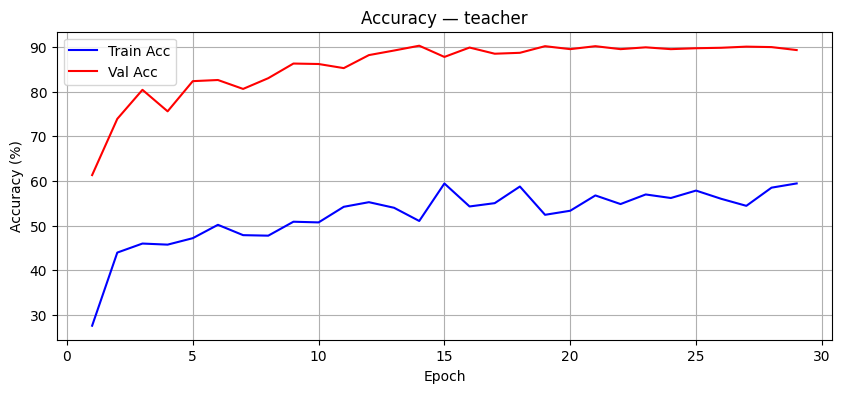

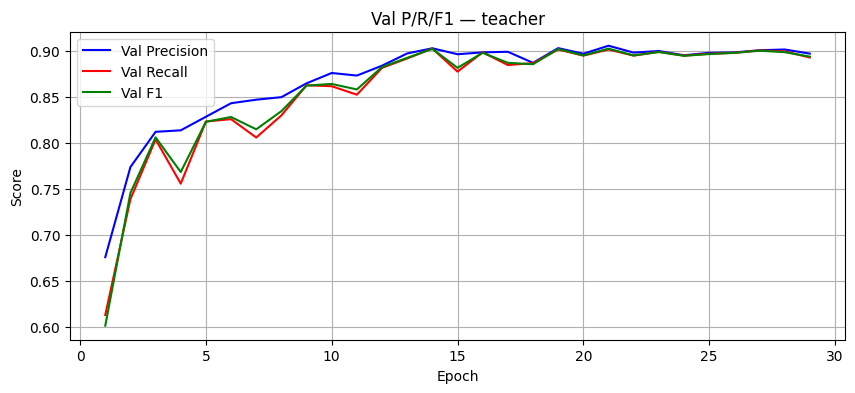

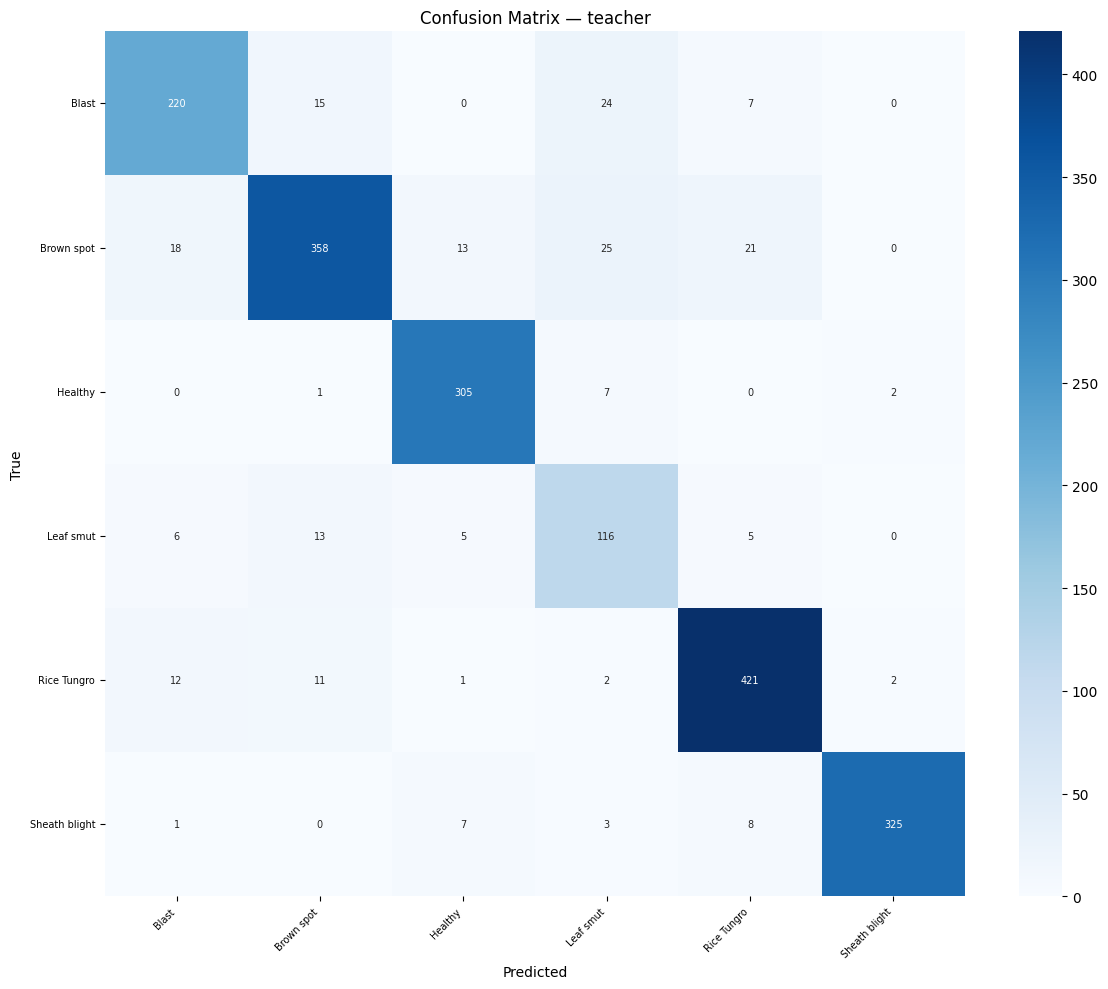

[Fold 1] Teacher — Acc:90.28%  F1:0.9024

[Fold 1] Training Student...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 216MB/s]
Student Epochs:   1%|          | 1/100 [01:11<1:57:44, 71.36s/it]

[Student] Epoch   1 | T-Loss:1.4302 T-Acc:37.12% | V-Loss:1.0527 V-Acc:76.46% V-F1:0.7628
  Val F1 improved (0.0000 → 0.7628). Saving model.


Student Epochs:   2%|▏         | 2/100 [02:22<1:56:10, 71.13s/it]

[Student] Epoch   2 | T-Loss:1.2974 T-Acc:43.41% | V-Loss:0.9790 V-Acc:80.60% V-F1:0.8042
  Val F1 improved (0.7628 → 0.8042). Saving model.


...

[Student] Epoch  67 | T-Loss:1.0101 T-Acc:57.42% | V-Loss:0.7474 V-Acc:91.04% V-F1:0.9107
  EarlyStopping: 13/15


Student Epochs:  68%|██████▊   | 68/100 [1:20:00<37:36, 70.52s/it]

[Student] Epoch  68 | T-Loss:1.0310 T-Acc:55.14% | V-Loss:0.7645 V-Acc:90.43% V-F1:0.9044
  EarlyStopping: 14/15


Student Epochs:  68%|██████▊   | 68/100 [1:21:10<38:12, 71.63s/it]

[Student] Epoch  69 | T-Loss:0.9966 T-Acc:58.16% | V-Loss:0.7866 V-Acc:91.30% V-F1:0.9129
  EarlyStopping: 15/15
Early stopping triggered (Student).


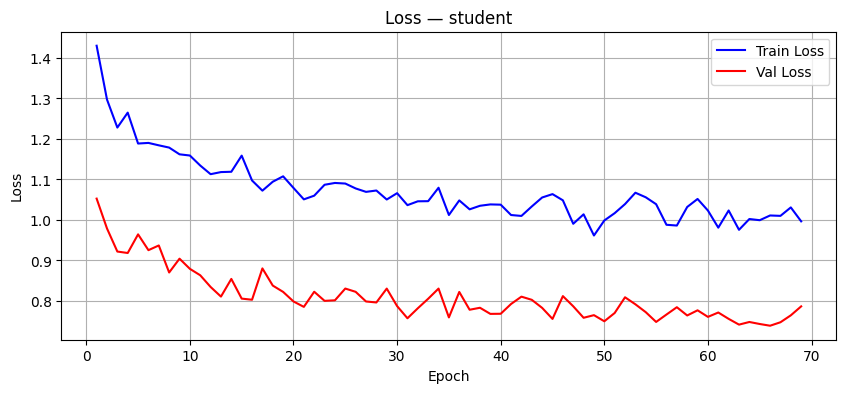

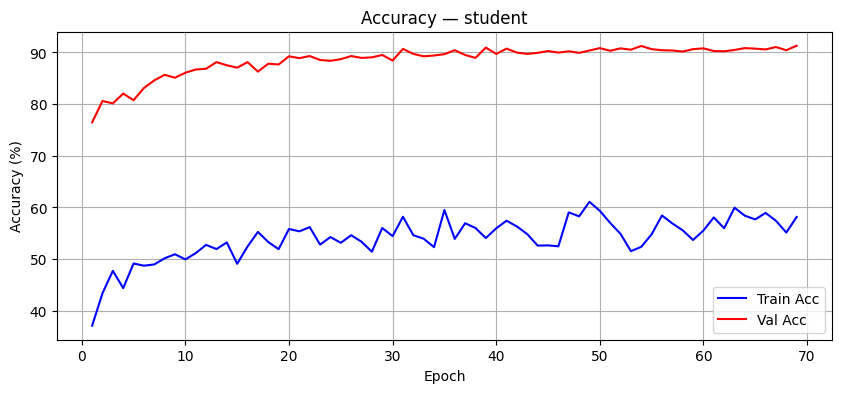

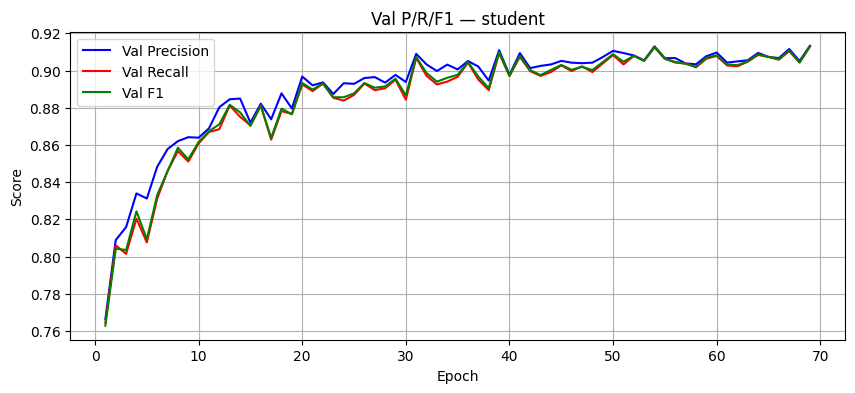

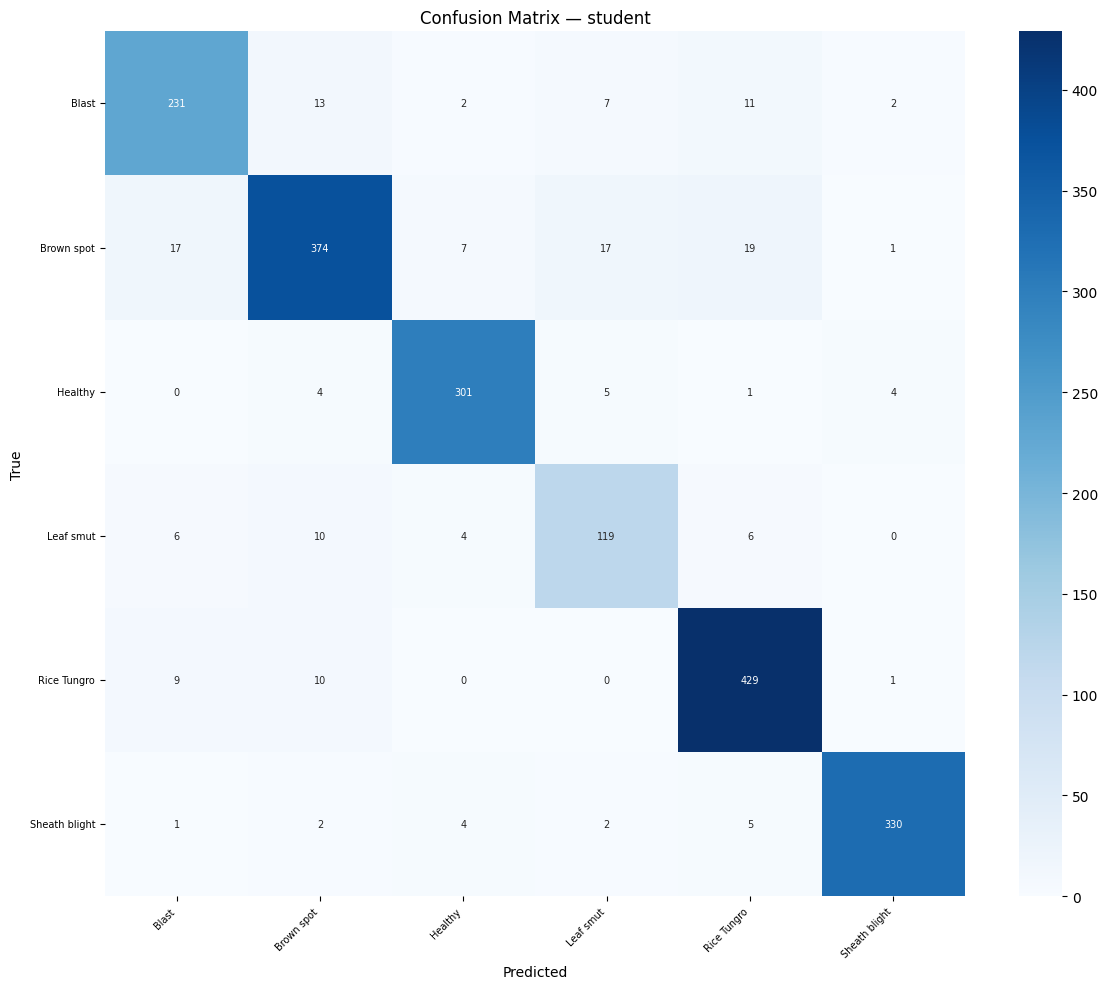

  [Clean FP32] → /content/drive/MyDrive/Research/Model_save/RiceLeafDiseaseBD_CV/clean_student_fp32_fold1.pt  (15.32 MB)
[Fold 1] Student — Acc:91.25%  F1:0.9126

[Fold 1] QAT fine-tuning...


/tmp/ipykernel_922/3063416250.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_922/3063416250.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_922/3063416250.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[QAT] Epoch   1 | T-Loss:0.9997 T-Acc:55.09% | V-Loss:0.5242 V-Acc:90.63%
[QAT] Epoch   2 | T-Loss:0.9739 T-Acc:58.28% | V-Loss:0.5159 V-Acc:90.58%
[QAT] Epoch   3 | T-Loss:0.9795 T-Acc:58.06% | V-Loss:0.5221 V-Acc:90.69%
[QAT] Epoch   4 | T-Loss:0.9725 T-Acc:57.45% | V-Loss:0.5072 V-Acc:90.33%
[QAT] Epoch   5 | T-Loss:0.9910 T-Acc:58.06% | V-Loss:0.5097 V-Acc:90.84%
[QAT] Epoch   6 | T-Loss:0.9628 T-Acc:59.42% | V-Loss:0.5220 V-Acc:90.84%
[QAT] Epoch   7 | T-Loss:0.9889 T-Acc:55.91% | V-Loss:0.5263 V-Acc:90.53%
[QAT] Epoch   8 | T-Loss:0.9812 T-Acc:56.84% | V-Loss:0.5126 V-Acc:90.69%
[QAT] Epoch   9 | T-Loss:0.9604 T-Acc:57.98% | V-Loss:0.5093 V-Acc:90.89%
[QAT] Epoch  10 | T-Loss:1.0002 T-Acc:54.12% | V-Loss:0.5162 V-Acc:90.79%
[QAT] Epoch  11 | T-Loss:0.9854 T-Acc:54.61% | V-Loss:0.5333 V-Acc:90.53%
[QAT] Epoch  12 | T-Loss:0.9979 T-Acc:55.58% | V-Loss:0.5191 V-Acc:90.89%
[QAT] Epoch  13 | T-Loss:1.0002 T-Acc:54.70% | V-Loss:0.5191 V-Acc:90.89%
[QAT] Epoch  14 | T-Loss:0.9937 T-Acc:

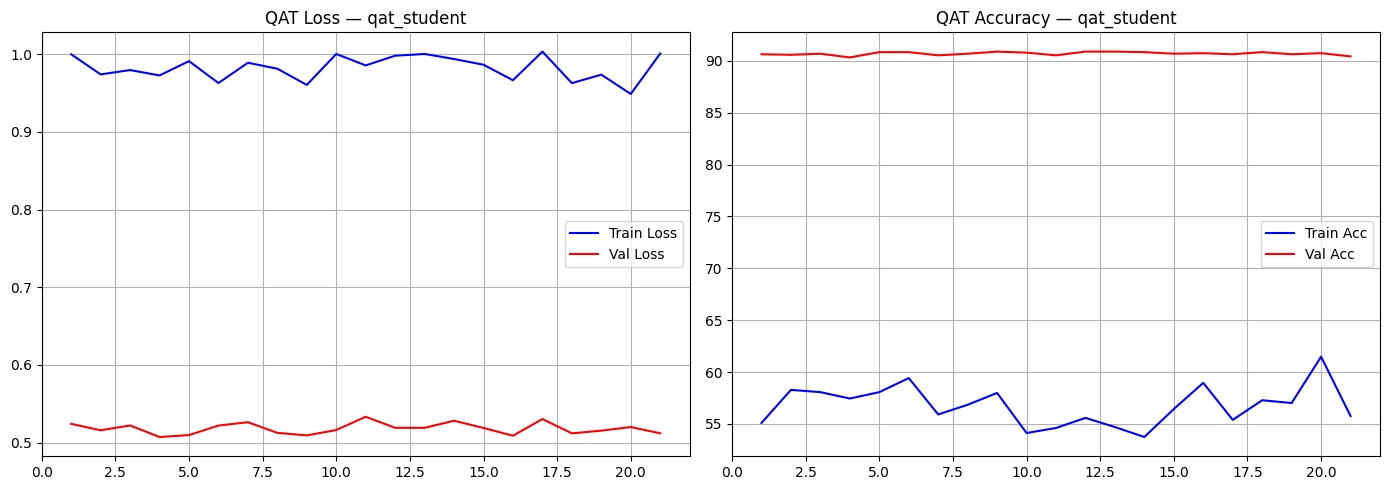

[Fold 1] QAT FP16 — Acc:90.89%  F1:0.9088
Fold 1 complete — results saved.

FOLD 2/5  |  train=7816  val=1954
Class weights (min/max): 0.726 / 2.246

[Fold 2] Training Teacher...


[Teacher] Epoch   1 | T-Loss:1.6687 T-Acc:28.60% | V-Loss:1.2795 V-Acc:63.31% V-F1:0.6353 | LR:1.00e-05
  Val F1 improved (0.0000 → 0.6353). Saving model.


[Teacher] Epoch   2 | T-Loss:1.3780 T-Acc:39.64% | V-Loss:1.0710 V-Acc:71.95% V-F1:0.7251 | LR:2.80e-05
  Val F1 improved (0.6353 → 0.7251). Saving model.


[Teacher] Epoch   3 | T-Loss:1.2612 T-Acc:45.71% | V-Loss:0.9971 V-Acc:75.08% V-F1:0.7559 | LR:4.60e-05
  Val F1 improved (0.7251 → 0.7559). Saving model.


[Teacher] Epoch   4 | T-Loss:1.2335 T-Acc:45.04% | V-Loss:0.9686 V-Acc:77.79% V-F1:0.7901 | LR:6.40e-05
  Val F1 improved (0.7559 → 0.7901). Saving model.


...

[Teacher] Epoch  38 | T-Loss:0.7844 T-Acc:61.66% | V-Loss:0.7697 V-Acc:89.10% V-F1:0.8904 | LR:7.48e-05
  EarlyStopping: 11/15


[Teacher] Epoch  39 | T-Loss:0.8173 T-Acc:57.93% | V-Loss:0.7442 V-Acc:89.82% V-F1:0.8983 | LR:7.33e-05
  EarlyStopping: 12/15


[Teacher] Epoch  40 | T-Loss:0.8166 T-Acc:60.50% | V-Loss:0.7654 V-Acc:89.36% V-F1:0.8933 | LR:7.19e-05
  EarlyStopping: 13/15


[Teacher] Epoch  41 | T-Loss:0.7868 T-Acc:58.74% | V-Loss:0.7503 V-Acc:89.66% V-F1:0.8967 | LR:7.04e-05
  EarlyStopping: 14/15


[Teacher] Epoch  42 | T-Loss:0.8317 T-Acc:60.88% | V-Loss:0.7499 V-Acc:90.28% V-F1:0.9030 | LR:6.89e-05
  EarlyStopping: 15/15
Early stopping triggered (Teacher).


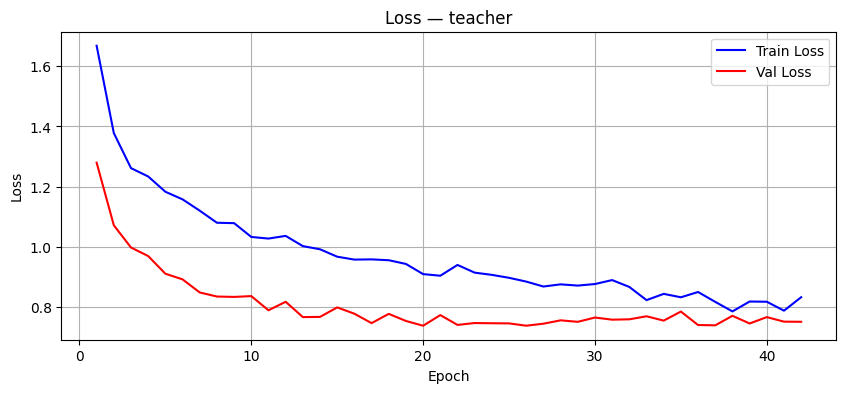

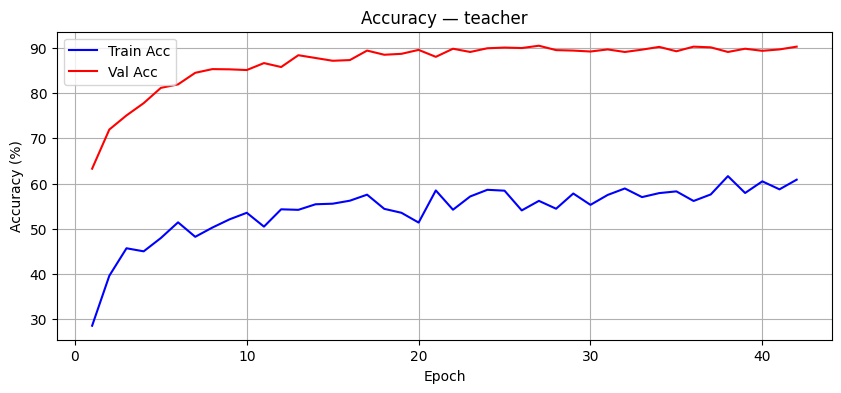

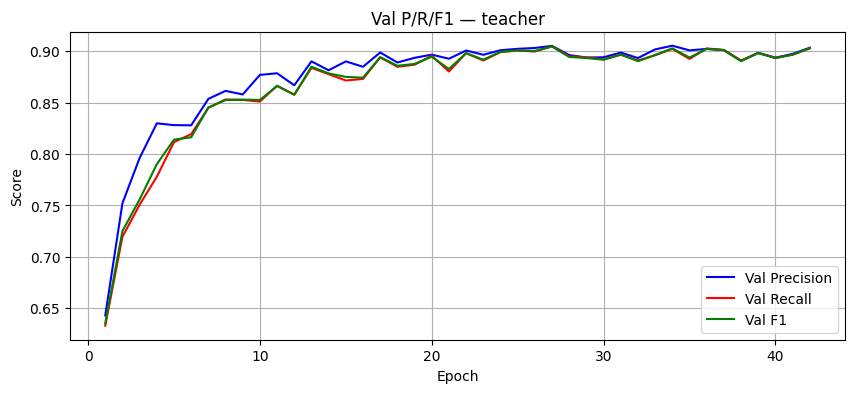

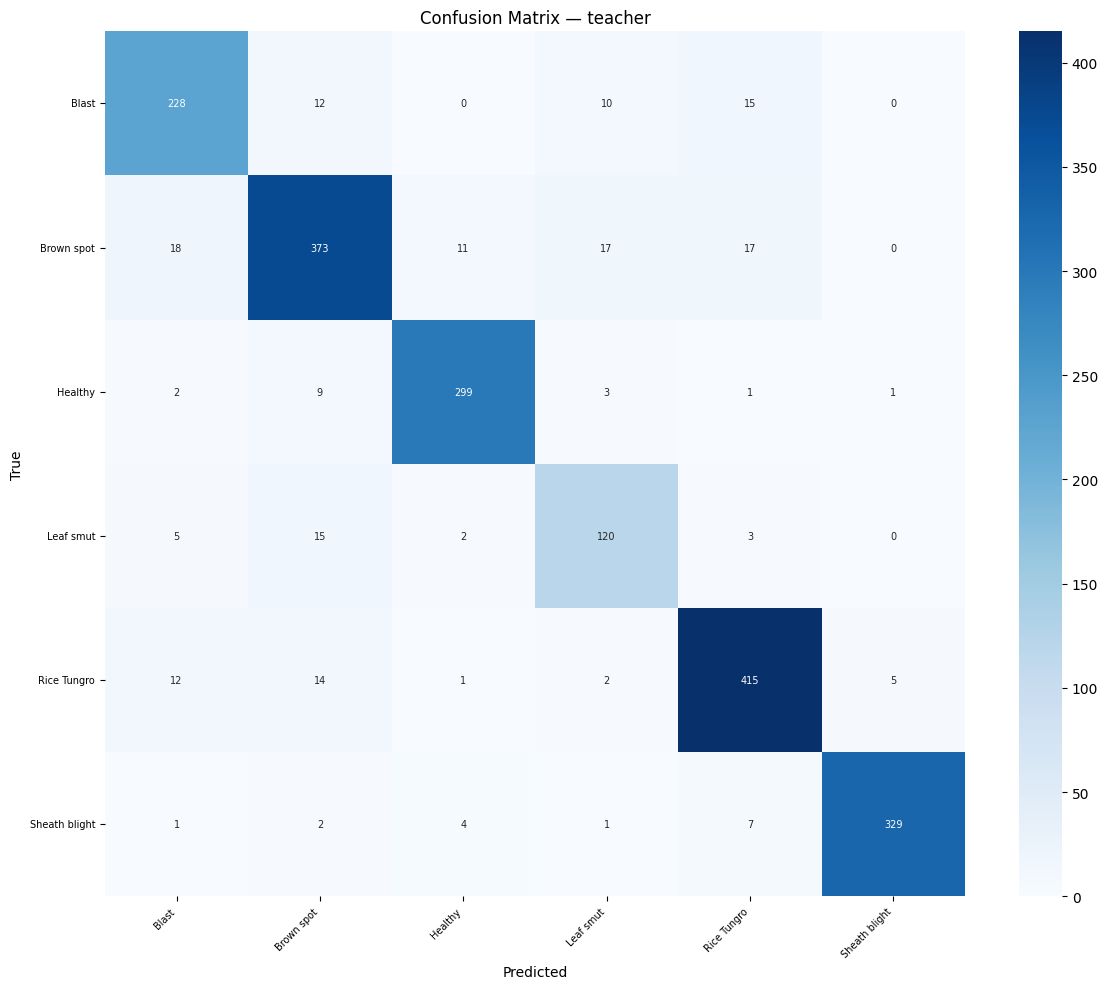

[Fold 2] Teacher — Acc:90.48%  F1:0.9045

[Fold 2] Training Student...


Student Epochs:   1%|          | 1/100 [01:10<1:55:35, 70.05s/it]

[Student] Epoch   1 | T-Loss:1.3954 T-Acc:35.72% | V-Loss:1.1233 V-Acc:70.62% V-F1:0.7078
  Val F1 improved (0.0000 → 0.7078). Saving model.


Student Epochs:   2%|▏         | 2/100 [02:20<1:55:11, 70.52s/it]

[Student] Epoch   2 | T-Loss:1.2661 T-Acc:42.35% | V-Loss:1.0103 V-Acc:76.46% V-F1:0.7634
  Val F1 improved (0.7078 → 0.7634). Saving model.


...

[Student] Epoch  79 | T-Loss:0.9187 T-Acc:60.53% | V-Loss:0.7803 V-Acc:90.99% V-F1:0.9101
  EarlyStopping: 13/15


Student Epochs:  80%|████████  | 80/100 [1:34:05<23:31, 70.56s/it]

[Student] Epoch  80 | T-Loss:0.9853 T-Acc:54.58% | V-Loss:0.7950 V-Acc:90.43% V-F1:0.9047
  EarlyStopping: 14/15


Student Epochs:  80%|████████  | 80/100 [1:35:15<23:48, 71.45s/it]

[Student] Epoch  81 | T-Loss:0.9297 T-Acc:59.99% | V-Loss:0.7798 V-Acc:90.74% V-F1:0.9076
  EarlyStopping: 15/15
Early stopping triggered (Student).


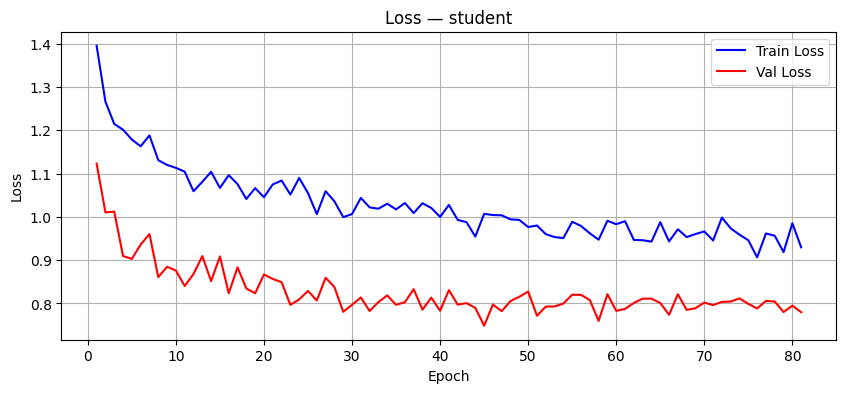

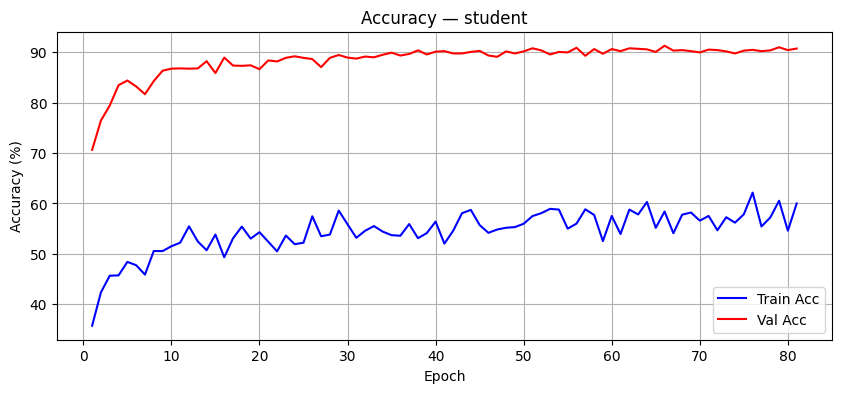

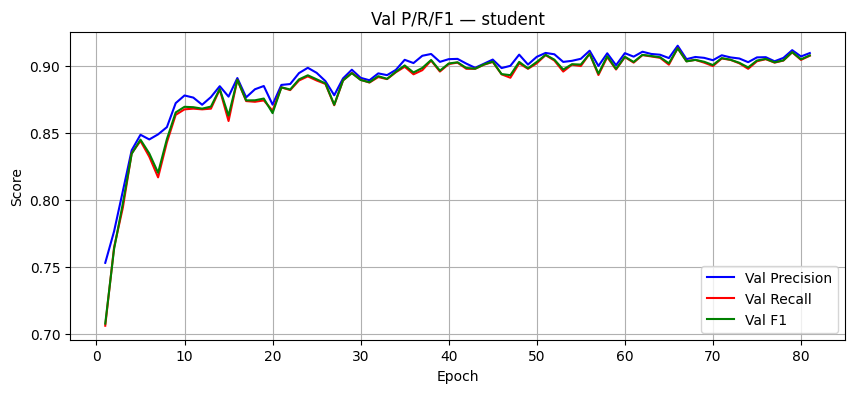

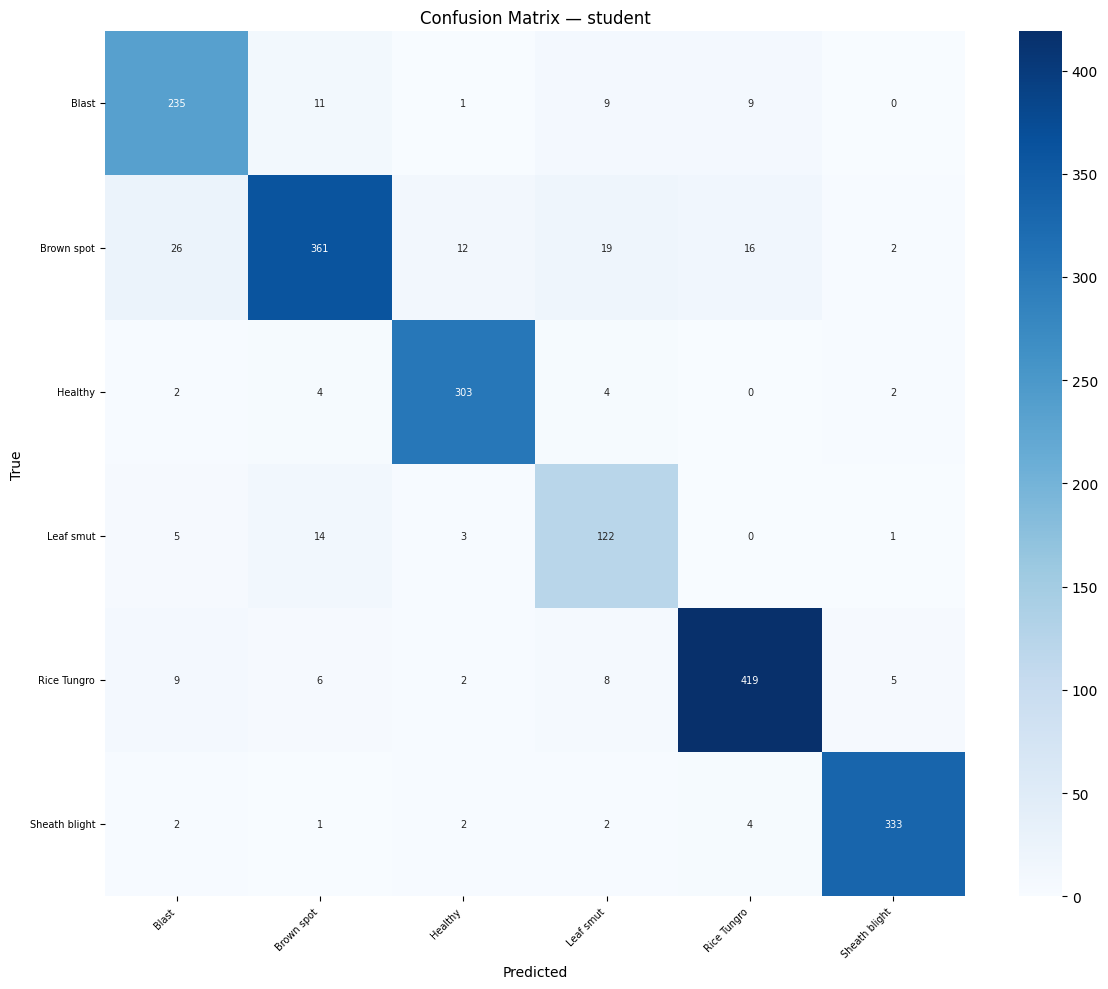

  [Clean FP32] → /content/drive/MyDrive/Research/Model_save/RiceLeafDiseaseBD_CV/clean_student_fp32_fold2.pt  (15.32 MB)
[Fold 2] Student — Acc:91.30%  F1:0.9130

[Fold 2] QAT fine-tuning...


/tmp/ipykernel_922/3063416250.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_922/3063416250.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_922/3063416250.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[QAT] Epoch   1 | T-Loss:0.9561 T-Acc:56.22% | V-Loss:0.5016 V-Acc:90.94%
[QAT] Epoch   2 | T-Loss:0.9321 T-Acc:56.78% | V-Loss:0.4929 V-Acc:91.20%
[QAT] Epoch   3 | T-Loss:0.9465 T-Acc:56.33% | V-Loss:0.5113 V-Acc:90.74%
[QAT] Epoch   4 | T-Loss:0.9451 T-Acc:58.25% | V-Loss:0.5072 V-Acc:90.79%
[QAT] Epoch   5 | T-Loss:0.9397 T-Acc:58.62% | V-Loss:0.4984 V-Acc:90.84%
[QAT] Epoch   6 | T-Loss:0.9467 T-Acc:55.72% | V-Loss:0.5064 V-Acc:90.94%
[QAT] Epoch   7 | T-Loss:0.9344 T-Acc:58.18% | V-Loss:0.5179 V-Acc:90.58%
[QAT] Epoch   8 | T-Loss:0.9221 T-Acc:58.64% | V-Loss:0.5122 V-Acc:90.63%
[QAT] Epoch   9 | T-Loss:0.9196 T-Acc:60.82% | V-Loss:0.5152 V-Acc:90.74%
[QAT] Epoch  10 | T-Loss:0.9266 T-Acc:58.44% | V-Loss:0.5070 V-Acc:90.63%
[QAT] Epoch  11 | T-Loss:0.9381 T-Acc:56.78% | V-Loss:0.5002 V-Acc:90.74%
[QAT] Epoch  12 | T-Loss:0.9198 T-Acc:59.28% | V-Loss:0.5063 V-Acc:90.94%
[QAT] Epoch  13 | T-Loss:0.9060 T-Acc:59.63% | V-Loss:0.5045 V-Acc:90.89%
[QAT] Epoch  14 | T-Loss:0.9185 T-Acc:

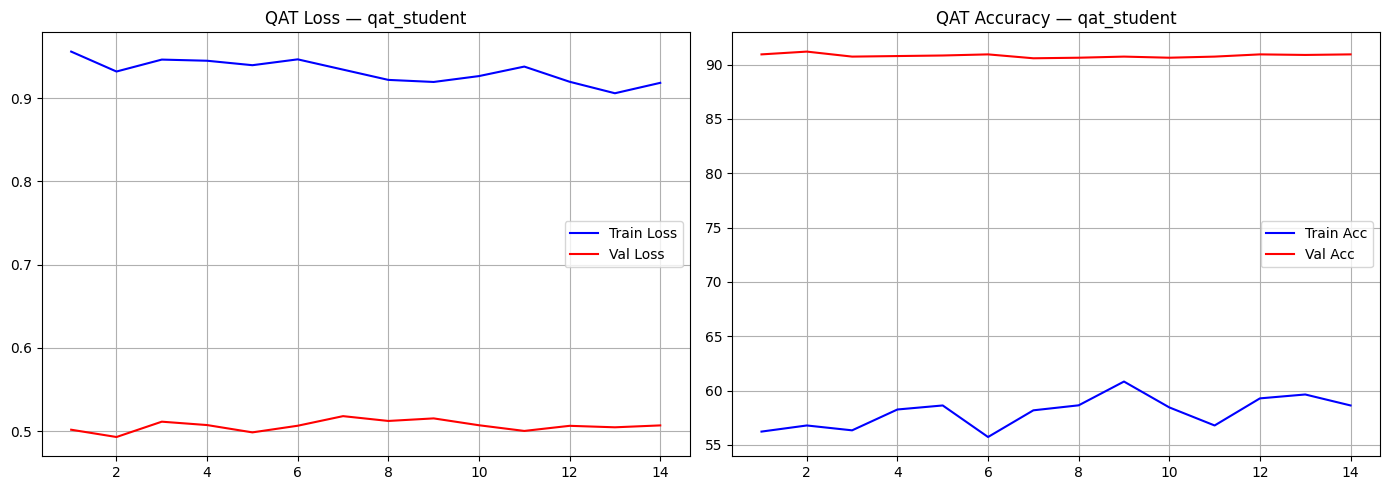

[Fold 2] QAT FP16 — Acc:91.20%  F1:0.9118
Fold 2 complete — results saved.

FOLD 3/5  |  train=7816  val=1954
Class weights (min/max): 0.726 / 2.246

[Fold 3] Training Teacher...


[Teacher] Epoch   1 | T-Loss:1.6867 T-Acc:27.84% | V-Loss:1.3217 V-Acc:58.90% V-F1:0.5970 | LR:1.00e-05
  Val F1 improved (0.0000 → 0.5970). Saving model.


[Teacher] Epoch   2 | T-Loss:1.4046 T-Acc:41.26% | V-Loss:1.0406 V-Acc:74.97% V-F1:0.7453 | LR:2.80e-05
  Val F1 improved (0.5970 → 0.7453). Saving model.


[Teacher] Epoch   3 | T-Loss:1.2638 T-Acc:44.26% | V-Loss:1.0462 V-Acc:71.70% V-F1:0.7289 | LR:4.60e-05
  EarlyStopping: 1/15


[Teacher] Epoch   4 | T-Loss:1.2151 T-Acc:47.93% | V-Loss:0.9368 V-Acc:80.04% V-F1:0.8074 | LR:6.40e-05
  Val F1 improved (0.7453 → 0.8074). Saving model.


...

[Teacher] Epoch  52 | T-Loss:0.7828 T-Acc:54.93% | V-Loss:0.7614 V-Acc:89.20% V-F1:0.8913 | LR:5.30e-05
  EarlyStopping: 11/15


[Teacher] Epoch  53 | T-Loss:0.7713 T-Acc:56.31% | V-Loss:0.7461 V-Acc:90.23% V-F1:0.9024 | LR:5.13e-05
  EarlyStopping: 12/15


[Teacher] Epoch  54 | T-Loss:0.7757 T-Acc:60.30% | V-Loss:0.7565 V-Acc:90.07% V-F1:0.9017 | LR:4.97e-05
  EarlyStopping: 13/15


[Teacher] Epoch  55 | T-Loss:0.8040 T-Acc:62.56% | V-Loss:0.7423 V-Acc:90.23% V-F1:0.9019 | LR:4.80e-05
  EarlyStopping: 14/15


[Teacher] Epoch  56 | T-Loss:0.8150 T-Acc:57.34% | V-Loss:0.7367 V-Acc:90.43% V-F1:0.9044 | LR:4.64e-05
  EarlyStopping: 15/15
Early stopping triggered (Teacher).


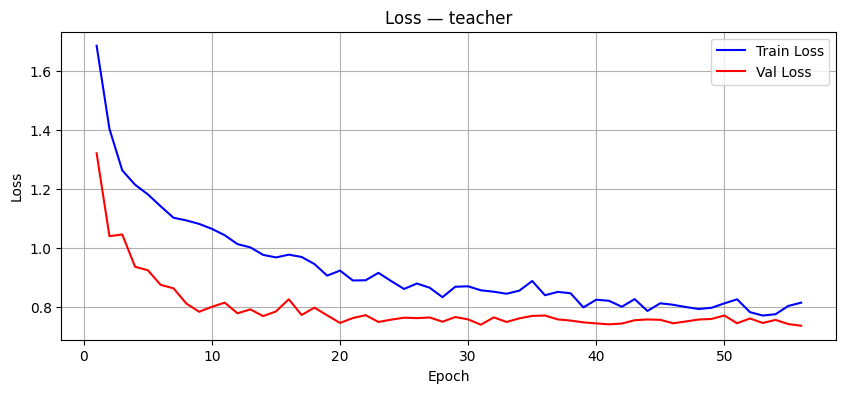

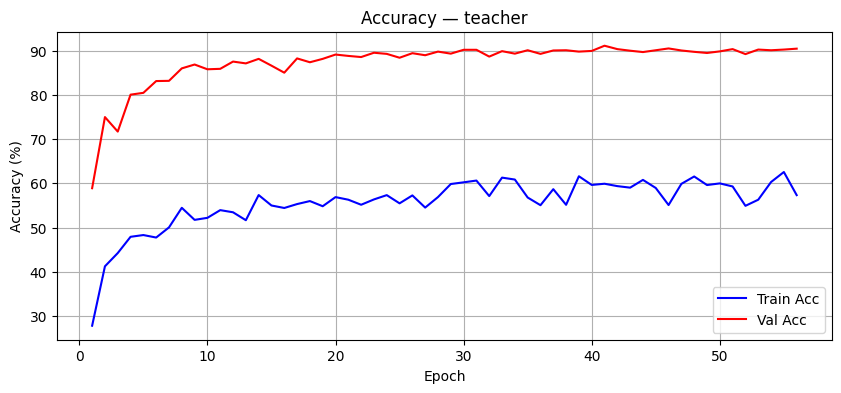

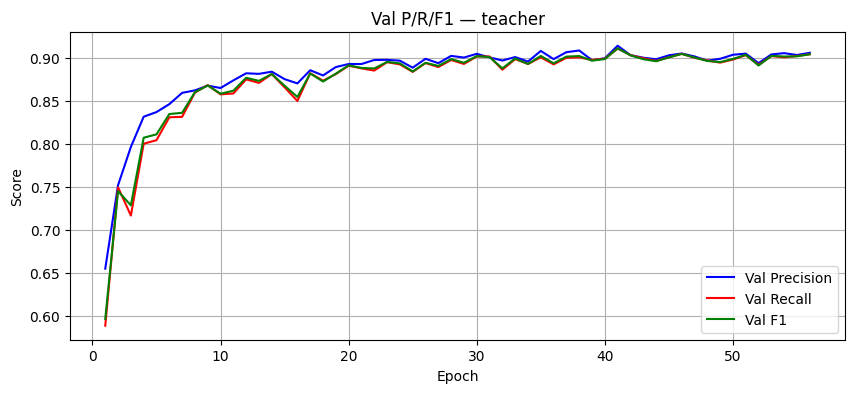

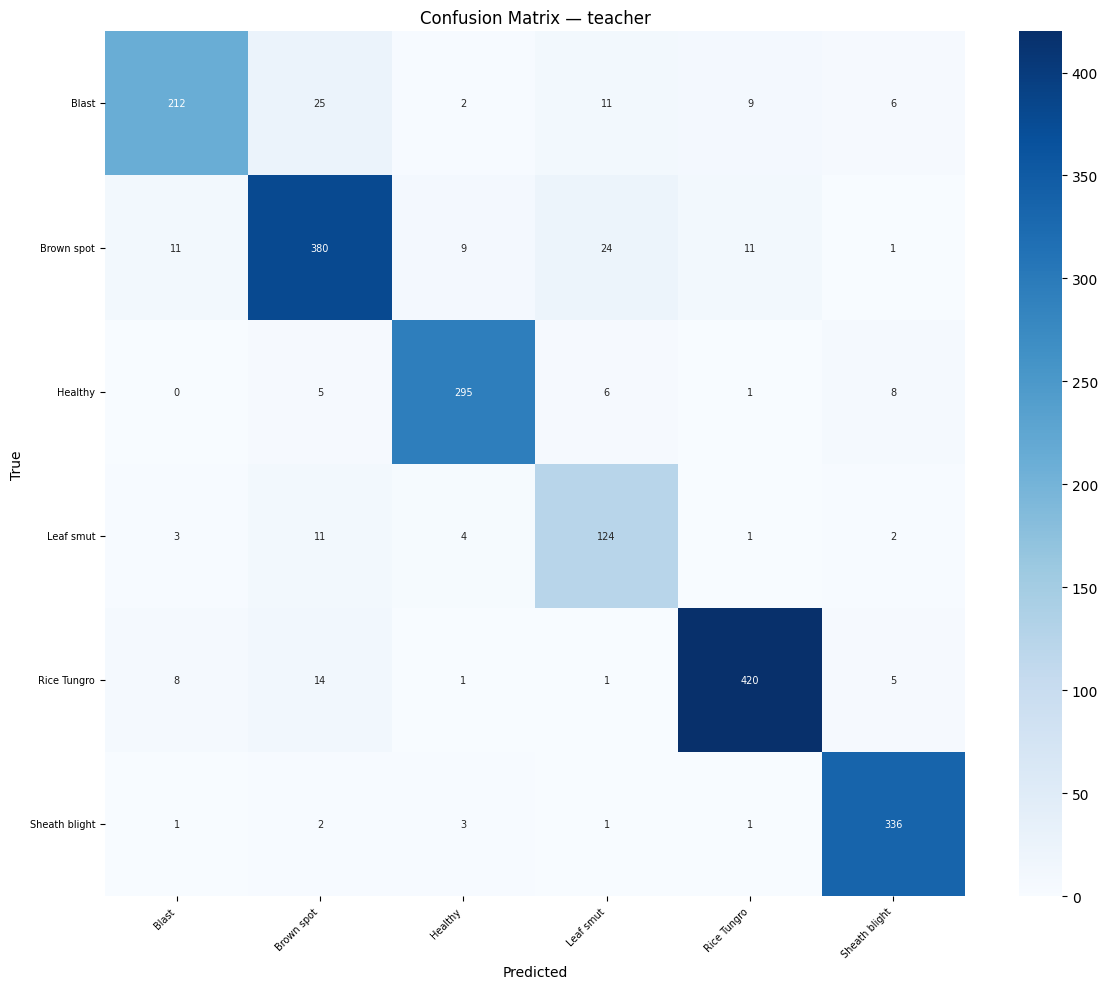

[Fold 3] Teacher — Acc:91.10%  F1:0.9111

[Fold 3] Training Student...


Student Epochs:   1%|          | 1/100 [01:10<1:56:17, 70.48s/it]

[Student] Epoch   1 | T-Loss:1.4048 T-Acc:35.07% | V-Loss:1.1608 V-Acc:70.37% V-F1:0.7117
  Val F1 improved (0.0000 → 0.7117). Saving model.


Student Epochs:   2%|▏         | 2/100 [02:20<1:55:07, 70.49s/it]

[Student] Epoch   2 | T-Loss:1.2689 T-Acc:45.33% | V-Loss:1.0879 V-Acc:73.69% V-F1:0.7431
  Val F1 improved (0.7117 → 0.7431). Saving model.


...

[Student] Epoch  61 | T-Loss:0.9526 T-Acc:57.25% | V-Loss:0.8345 V-Acc:88.74% V-F1:0.8876
  EarlyStopping: 13/15


Student Epochs:  62%|██████▏   | 62/100 [1:12:46<44:37, 70.47s/it]

[Student] Epoch  62 | T-Loss:1.0011 T-Acc:54.02% | V-Loss:0.8244 V-Acc:89.15% V-F1:0.8918
  EarlyStopping: 14/15


Student Epochs:  62%|██████▏   | 62/100 [1:13:56<45:19, 71.56s/it]

[Student] Epoch  63 | T-Loss:0.9248 T-Acc:58.76% | V-Loss:0.8136 V-Acc:89.36% V-F1:0.8940
  EarlyStopping: 15/15
Early stopping triggered (Student).


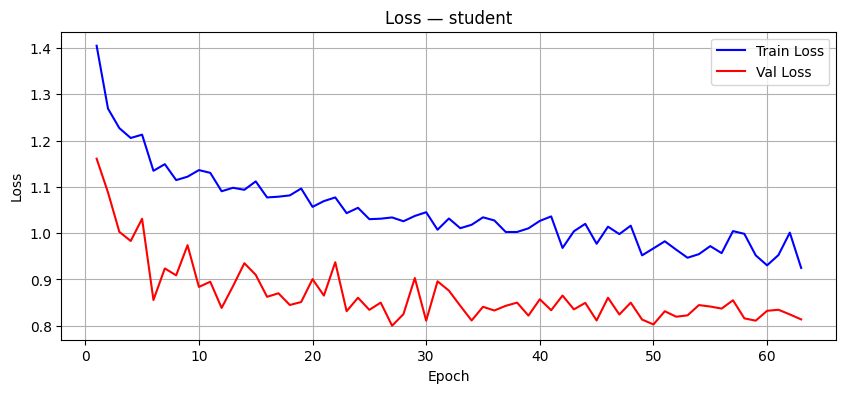

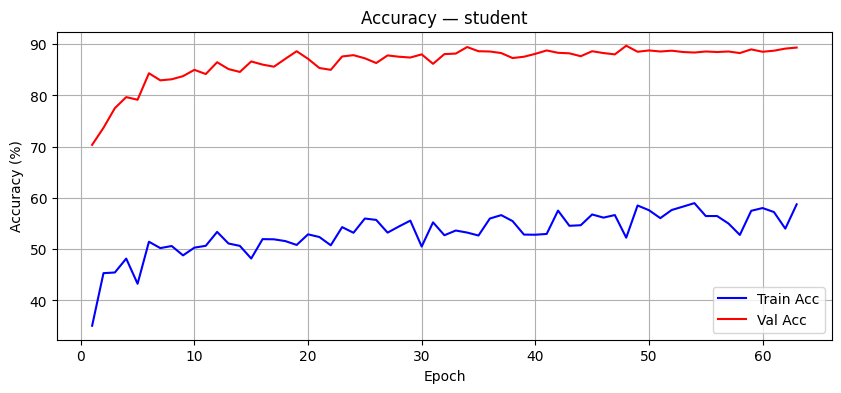

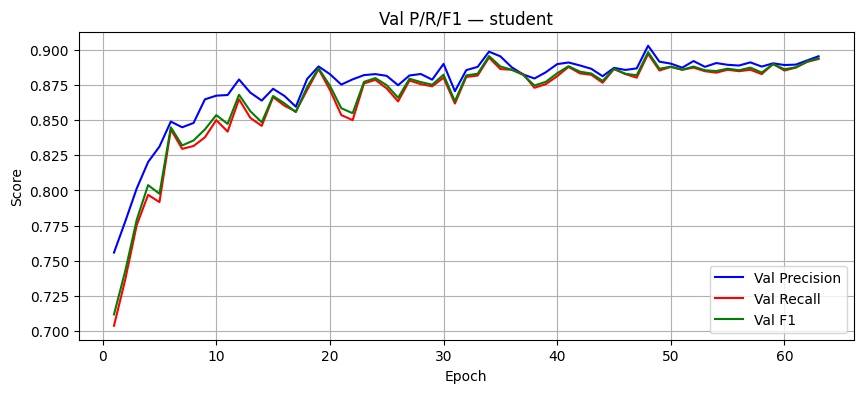

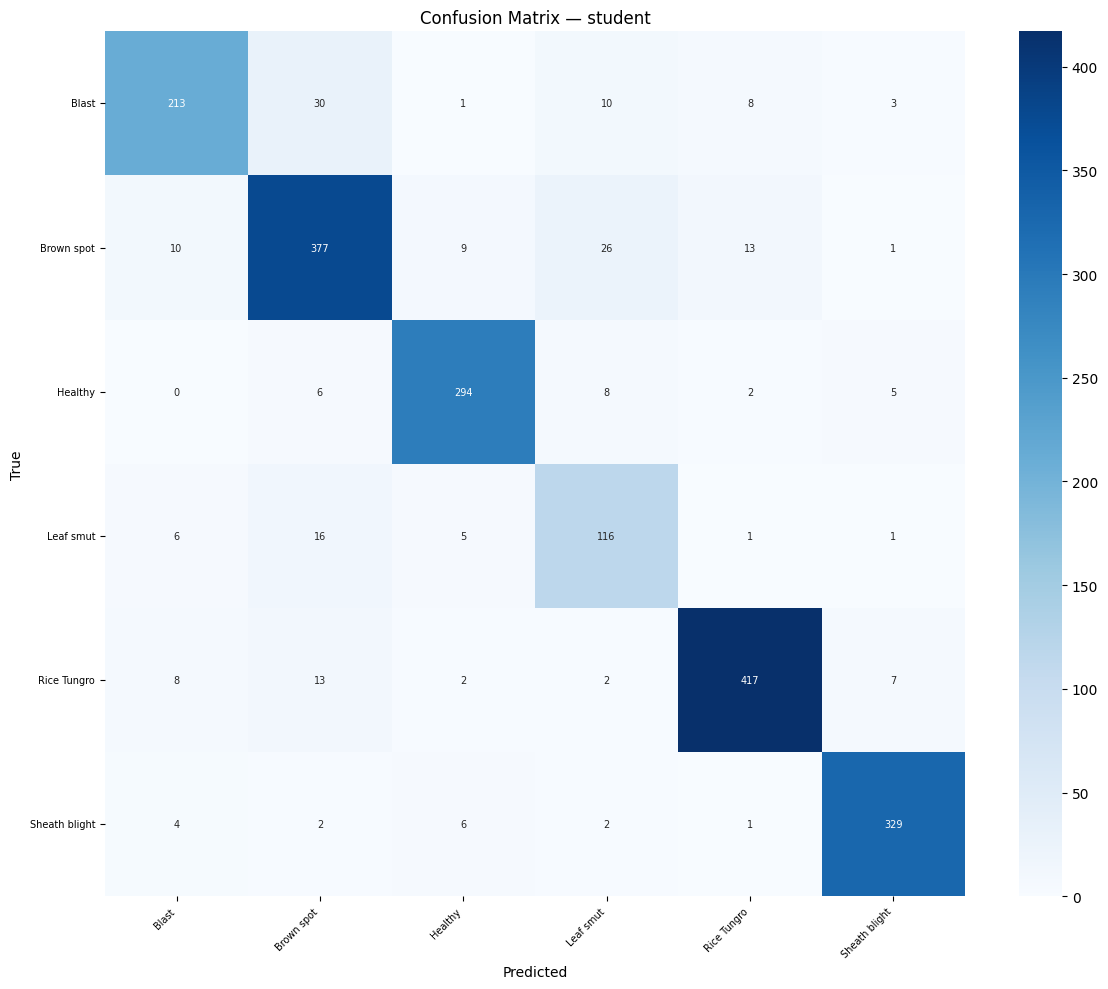

  [Clean FP32] → /content/drive/MyDrive/Research/Model_save/RiceLeafDiseaseBD_CV/clean_student_fp32_fold3.pt  (15.32 MB)
[Fold 3] Student — Acc:89.71%  F1:0.8985

[Fold 3] QAT fine-tuning...


/tmp/ipykernel_922/3063416250.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_922/3063416250.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_922/3063416250.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[QAT] Epoch   1 | T-Loss:0.9778 T-Acc:55.07% | V-Loss:0.5293 V-Acc:89.36%
[QAT] Epoch   2 | T-Loss:0.9495 T-Acc:56.45% | V-Loss:0.5222 V-Acc:89.51%
[QAT] Epoch   3 | T-Loss:0.9761 T-Acc:55.05% | V-Loss:0.5243 V-Acc:89.10%
[QAT] Epoch   4 | T-Loss:0.9224 T-Acc:58.52% | V-Loss:0.5188 V-Acc:89.20%
[QAT] Epoch   5 | T-Loss:0.9522 T-Acc:56.17% | V-Loss:0.5323 V-Acc:89.20%
[QAT] Epoch   6 | T-Loss:0.9449 T-Acc:56.28% | V-Loss:0.5278 V-Acc:89.00%
[QAT] Epoch   7 | T-Loss:0.9208 T-Acc:60.26% | V-Loss:0.5113 V-Acc:89.25%
[QAT] Epoch   8 | T-Loss:0.9402 T-Acc:57.86% | V-Loss:0.5255 V-Acc:89.15%
[QAT] Epoch   9 | T-Loss:0.9296 T-Acc:57.84% | V-Loss:0.5125 V-Acc:89.71%
[QAT] Epoch  10 | T-Loss:0.9422 T-Acc:57.34% | V-Loss:0.5080 V-Acc:89.61%
[QAT] Epoch  11 | T-Loss:0.9201 T-Acc:59.15% | V-Loss:0.5263 V-Acc:89.41%
[QAT] Epoch  12 | T-Loss:0.9433 T-Acc:57.50% | V-Loss:0.5323 V-Acc:89.56%
[QAT] Epoch  13 | T-Loss:0.9306 T-Acc:59.02% | V-Loss:0.5278 V-Acc:89.61%
[QAT] Epoch  14 | T-Loss:0.9775 T-Acc:

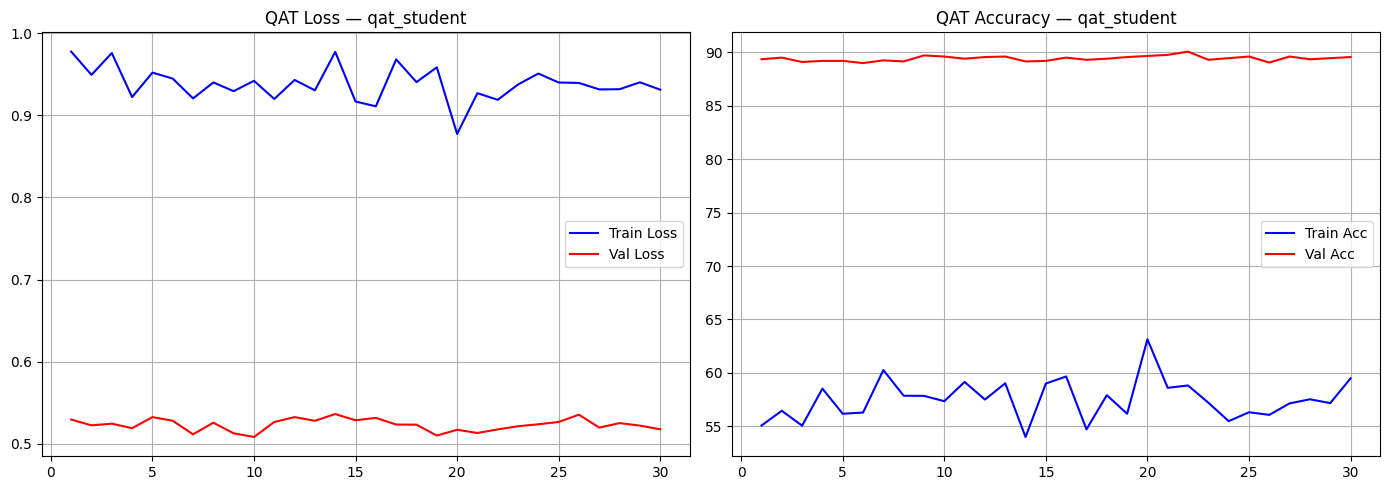

[Fold 3] QAT FP16 — Acc:90.02%  F1:0.9002
Fold 3 complete — results saved.

FOLD 4/5  |  train=7816  val=1954
Class weights (min/max): 0.725 / 2.246

[Fold 4] Training Teacher...


[Teacher] Epoch   1 | T-Loss:1.6457 T-Acc:30.81% | V-Loss:1.3101 V-Acc:58.34% V-F1:0.5993 | LR:1.00e-05
  Val F1 improved (0.0000 → 0.5993). Saving model.


[Teacher] Epoch   2 | T-Loss:1.3645 T-Acc:41.58% | V-Loss:1.0587 V-Acc:75.54% V-F1:0.7561 | LR:2.80e-05
  Val F1 improved (0.5993 → 0.7561). Saving model.


[Teacher] Epoch   3 | T-Loss:1.2540 T-Acc:44.18% | V-Loss:0.9834 V-Acc:77.84% V-F1:0.7829 | LR:4.60e-05
  Val F1 improved (0.7561 → 0.7829). Saving model.


[Teacher] Epoch   4 | T-Loss:1.2080 T-Acc:45.52% | V-Loss:0.9904 V-Acc:77.33% V-F1:0.7757 | LR:6.40e-05
  EarlyStopping: 1/15


...

[Teacher] Epoch  43 | T-Loss:0.8311 T-Acc:60.52% | V-Loss:0.7713 V-Acc:89.15% V-F1:0.8912 | LR:6.73e-05
  EarlyStopping: 11/15


[Teacher] Epoch  44 | T-Loss:0.8147 T-Acc:63.10% | V-Loss:0.8208 V-Acc:88.84% V-F1:0.8912 | LR:6.58e-05
  EarlyStopping: 12/15


[Teacher] Epoch  45 | T-Loss:0.7978 T-Acc:60.67% | V-Loss:0.7923 V-Acc:88.95% V-F1:0.8907 | LR:6.42e-05
  EarlyStopping: 13/15


[Teacher] Epoch  46 | T-Loss:0.8029 T-Acc:57.68% | V-Loss:0.7835 V-Acc:89.00% V-F1:0.8903 | LR:6.27e-05
  EarlyStopping: 14/15


[Teacher] Epoch  47 | T-Loss:0.8015 T-Acc:55.71% | V-Loss:0.7795 V-Acc:89.10% V-F1:0.8915 | LR:6.11e-05
  EarlyStopping: 15/15
Early stopping triggered (Teacher).


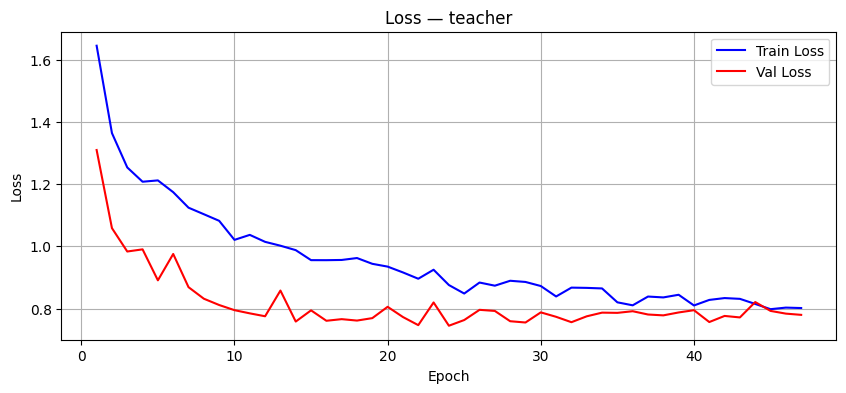

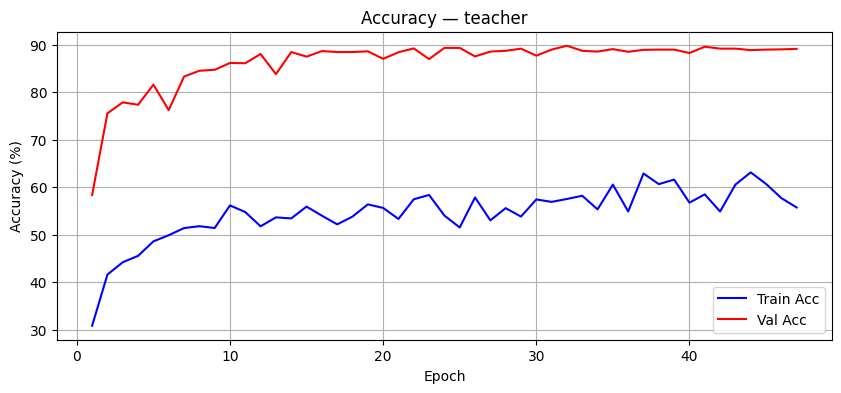

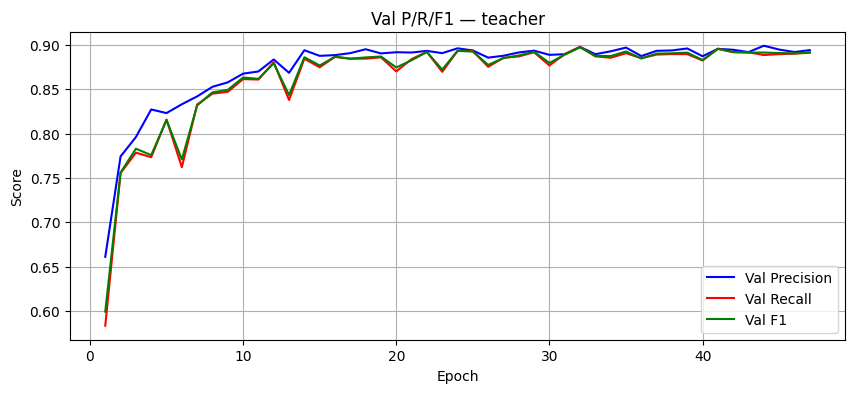

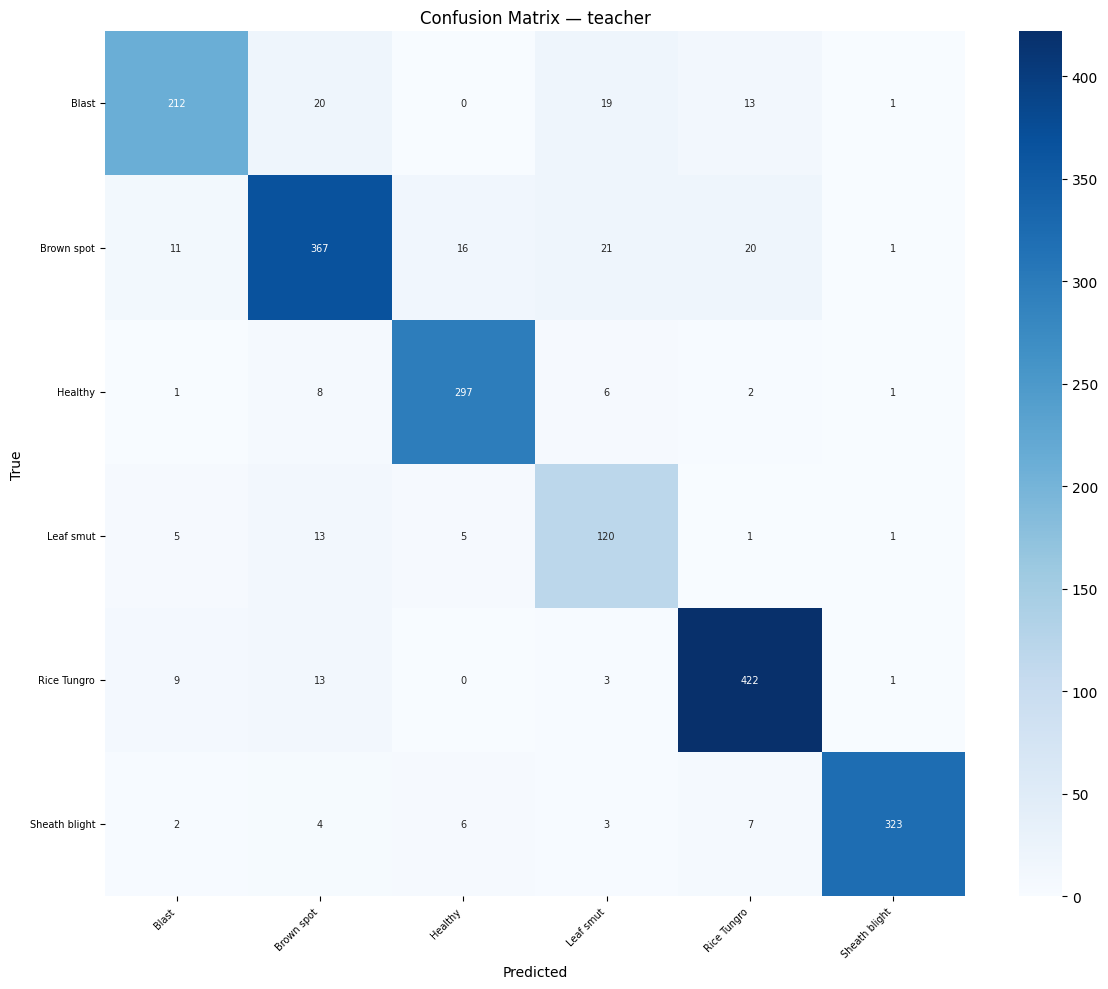

[Fold 4] Teacher — Acc:89.76%  F1:0.8972

[Fold 4] Training Student...


Student Epochs:   1%|          | 1/100 [01:10<1:56:12, 70.43s/it]

[Student] Epoch   1 | T-Loss:1.4428 T-Acc:37.86% | V-Loss:1.0996 V-Acc:72.98% V-F1:0.7404
  Val F1 improved (0.0000 → 0.7404). Saving model.


Student Epochs:   2%|▏         | 2/100 [02:20<1:54:43, 70.23s/it]

[Student] Epoch   2 | T-Loss:1.2848 T-Acc:46.99% | V-Loss:1.0336 V-Acc:76.20% V-F1:0.7664
  Val F1 improved (0.7404 → 0.7664). Saving model.


...

[Student] Epoch  63 | T-Loss:0.9866 T-Acc:58.50% | V-Loss:0.7966 V-Acc:89.56% V-F1:0.8967
  EarlyStopping: 13/15


Student Epochs:  64%|██████▍   | 64/100 [1:15:04<42:15, 70.44s/it]

[Student] Epoch  64 | T-Loss:1.0161 T-Acc:55.12% | V-Loss:0.8042 V-Acc:89.51% V-F1:0.8958
  EarlyStopping: 14/15


Student Epochs:  64%|██████▍   | 64/100 [1:16:14<42:53, 71.48s/it]

[Student] Epoch  65 | T-Loss:0.9596 T-Acc:60.53% | V-Loss:0.7901 V-Acc:89.41% V-F1:0.8947
  EarlyStopping: 15/15
Early stopping triggered (Student).


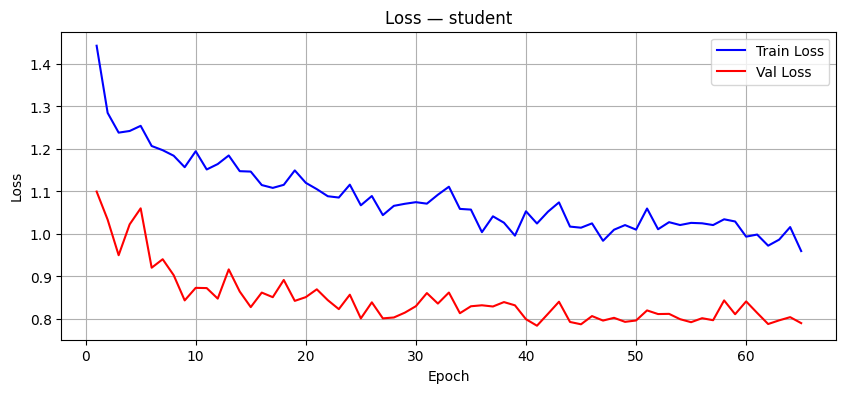

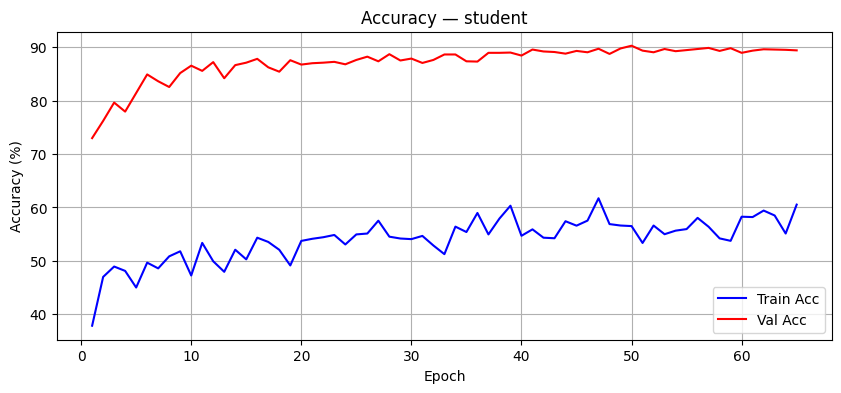

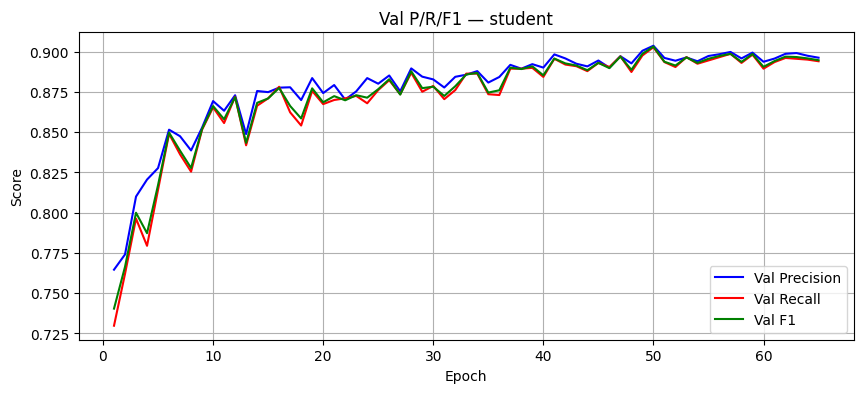

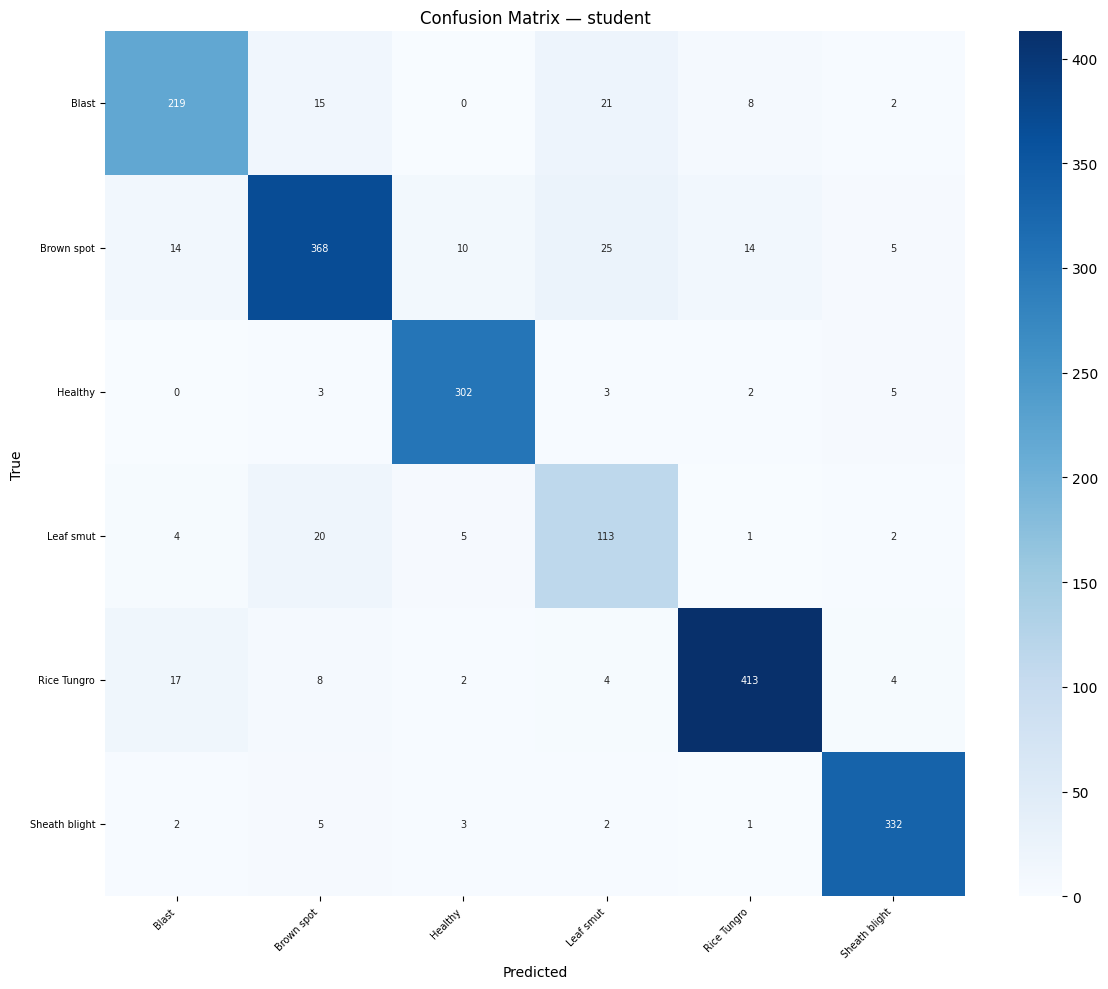

  [Clean FP32] → /content/drive/MyDrive/Research/Model_save/RiceLeafDiseaseBD_CV/clean_student_fp32_fold4.pt  (15.32 MB)
[Fold 4] Student — Acc:90.28%  F1:0.9032

[Fold 4] QAT fine-tuning...


/tmp/ipykernel_922/3063416250.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_922/3063416250.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_922/3063416250.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[QAT] Epoch   1 | T-Loss:0.9482 T-Acc:61.07% | V-Loss:0.5164 V-Acc:90.07%
[QAT] Epoch   2 | T-Loss:0.9976 T-Acc:56.60% | V-Loss:0.5345 V-Acc:90.23%
[QAT] Epoch   3 | T-Loss:0.9552 T-Acc:59.67% | V-Loss:0.5207 V-Acc:90.17%
[QAT] Epoch   4 | T-Loss:0.9562 T-Acc:59.08% | V-Loss:0.5201 V-Acc:90.12%
[QAT] Epoch   5 | T-Loss:0.9951 T-Acc:56.88% | V-Loss:0.5208 V-Acc:89.97%
[QAT] Epoch   6 | T-Loss:1.0305 T-Acc:52.85% | V-Loss:0.5258 V-Acc:90.02%
[QAT] Epoch   7 | T-Loss:1.0032 T-Acc:56.79% | V-Loss:0.5283 V-Acc:90.43%
[QAT] Epoch   8 | T-Loss:0.9691 T-Acc:57.92% | V-Loss:0.5237 V-Acc:90.17%
[QAT] Epoch   9 | T-Loss:1.0264 T-Acc:53.61% | V-Loss:0.5348 V-Acc:90.17%
[QAT] Epoch  10 | T-Loss:0.9863 T-Acc:58.03% | V-Loss:0.5256 V-Acc:90.17%
[QAT] Epoch  11 | T-Loss:0.9654 T-Acc:59.99% | V-Loss:0.5143 V-Acc:90.23%
[QAT] Epoch  12 | T-Loss:0.9958 T-Acc:56.31% | V-Loss:0.5217 V-Acc:90.28%
[QAT] Epoch  13 | T-Loss:0.9910 T-Acc:54.26% | V-Loss:0.5431 V-Acc:90.28%
[QAT] Epoch  14 | T-Loss:0.9752 T-Acc:

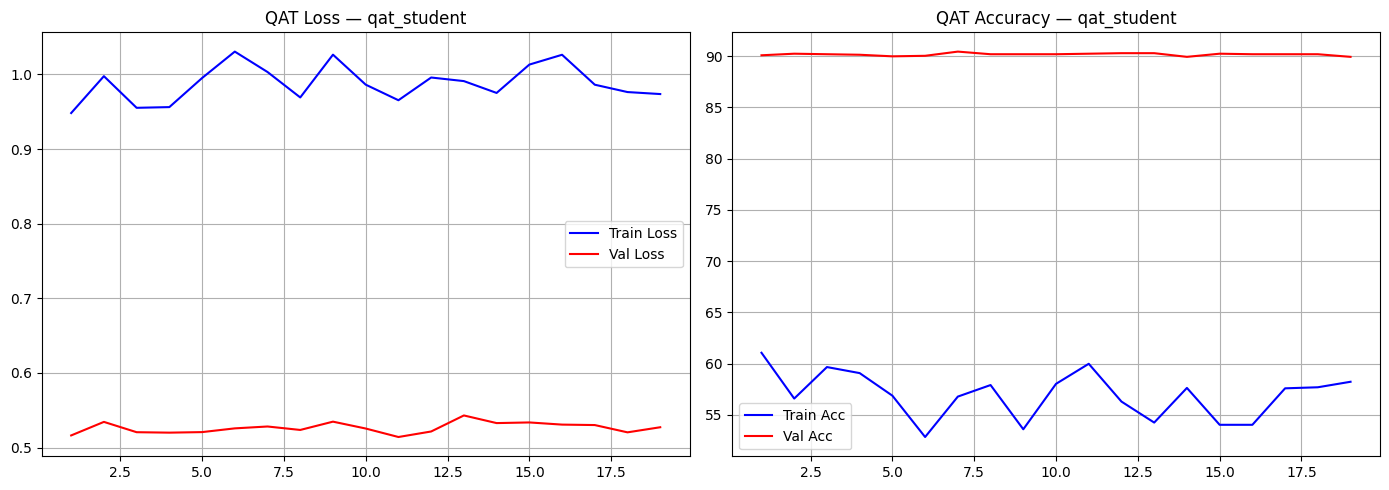

[Fold 4] QAT FP16 — Acc:90.38%  F1:0.9035
Fold 4 complete — results saved.

FOLD 5/5  |  train=7816  val=1954
Class weights (min/max): 0.726 / 2.246

[Fold 5] Training Teacher...


[Teacher] Epoch   1 | T-Loss:1.6910 T-Acc:26.70% | V-Loss:1.3032 V-Acc:62.54% V-F1:0.6253 | LR:1.00e-05
  Val F1 improved (0.0000 → 0.6253). Saving model.


[Teacher] Epoch   2 | T-Loss:1.3603 T-Acc:41.44% | V-Loss:1.0044 V-Acc:76.10% V-F1:0.7619 | LR:2.80e-05
  Val F1 improved (0.6253 → 0.7619). Saving model.


[Teacher] Epoch   3 | T-Loss:1.2883 T-Acc:44.15% | V-Loss:0.9654 V-Acc:76.87% V-F1:0.7709 | LR:4.60e-05
  Val F1 improved (0.7619 → 0.7709). Saving model.


[Teacher] Epoch   4 | T-Loss:1.2368 T-Acc:47.36% | V-Loss:0.9502 V-Acc:77.84% V-F1:0.7788 | LR:6.40e-05
  Val F1 improved (0.7709 → 0.7788). Saving model.


...

[Teacher] Epoch  47 | T-Loss:0.8127 T-Acc:60.03% | V-Loss:0.7536 V-Acc:89.56% V-F1:0.8958 | LR:6.11e-05
  EarlyStopping: 11/15


[Teacher] Epoch  48 | T-Loss:0.8027 T-Acc:58.30% | V-Loss:0.7665 V-Acc:89.56% V-F1:0.8954 | LR:5.95e-05
  EarlyStopping: 12/15


[Teacher] Epoch  49 | T-Loss:0.7881 T-Acc:59.95% | V-Loss:0.7690 V-Acc:89.56% V-F1:0.8959 | LR:5.78e-05
  EarlyStopping: 13/15


[Teacher] Epoch  50 | T-Loss:0.7955 T-Acc:57.13% | V-Loss:0.7632 V-Acc:89.82% V-F1:0.8980 | LR:5.62e-05
  EarlyStopping: 14/15


[Teacher] Epoch  51 | T-Loss:0.7955 T-Acc:56.22% | V-Loss:0.7601 V-Acc:89.71% V-F1:0.8977 | LR:5.46e-05
  EarlyStopping: 15/15
Early stopping triggered (Teacher).


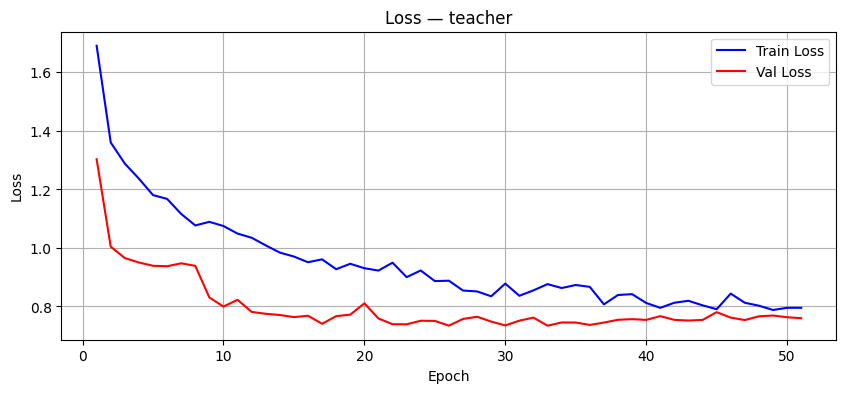

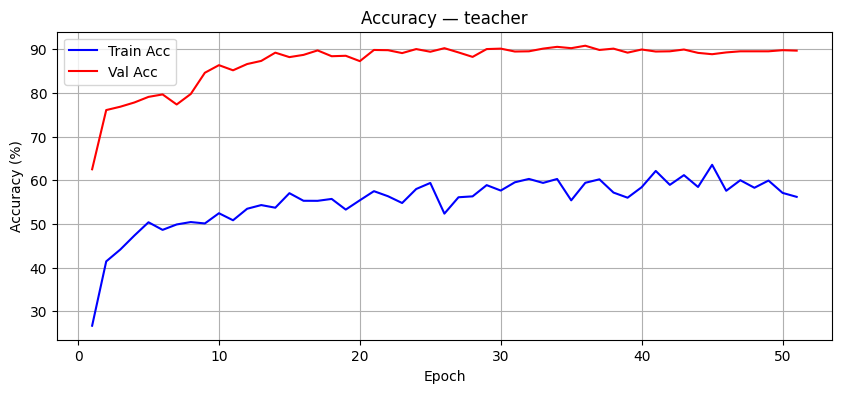

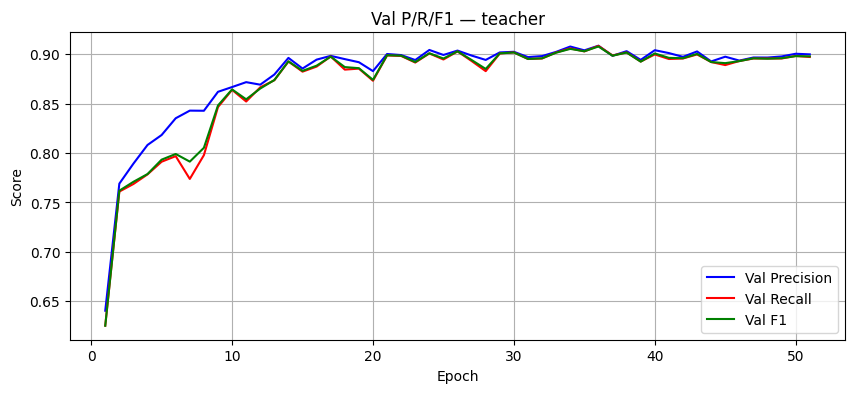

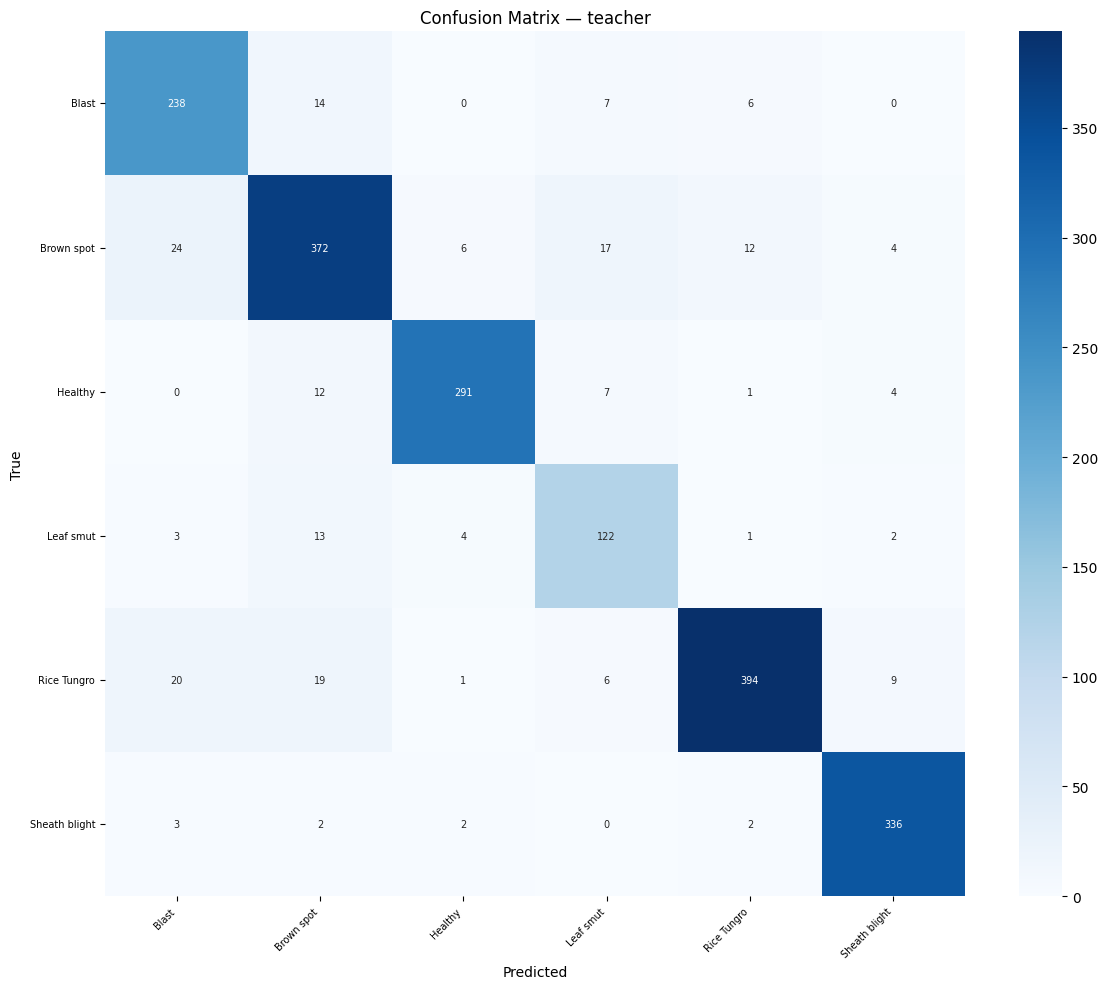

[Fold 5] Teacher — Acc:90.84%  F1:0.9077

[Fold 5] Training Student...


Student Epochs:   1%|          | 1/100 [01:10<1:56:16, 70.47s/it]

[Student] Epoch   1 | T-Loss:1.4403 T-Acc:36.54% | V-Loss:1.1116 V-Acc:73.64% V-F1:0.7363
  Val F1 improved (0.0000 → 0.7363). Saving model.


Student Epochs:   2%|▏         | 2/100 [02:21<1:55:12, 70.54s/it]

[Student] Epoch   2 | T-Loss:1.2963 T-Acc:42.87% | V-Loss:1.0454 V-Acc:76.77% V-F1:0.7722
  Val F1 improved (0.7363 → 0.7722). Saving model.


...

[Student] Epoch  58 | T-Loss:1.0028 T-Acc:55.30% | V-Loss:0.7909 V-Acc:89.76% V-F1:0.8980
  EarlyStopping: 13/15


Student Epochs:  59%|█████▉    | 59/100 [1:09:18<48:08, 70.46s/it]

[Student] Epoch  59 | T-Loss:0.9819 T-Acc:58.03% | V-Loss:0.8201 V-Acc:89.46% V-F1:0.8942
  EarlyStopping: 14/15


Student Epochs:  59%|█████▉    | 59/100 [1:10:28<48:58, 71.67s/it]

[Student] Epoch  60 | T-Loss:0.9786 T-Acc:58.12% | V-Loss:0.8169 V-Acc:90.12% V-F1:0.9012
  EarlyStopping: 15/15
Early stopping triggered (Student).


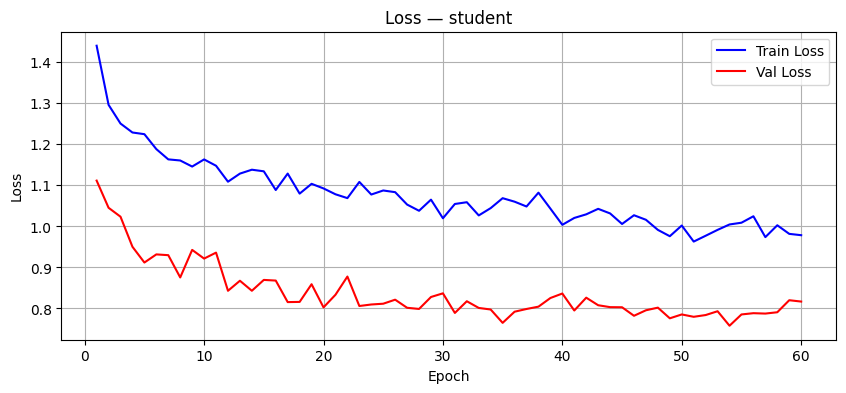

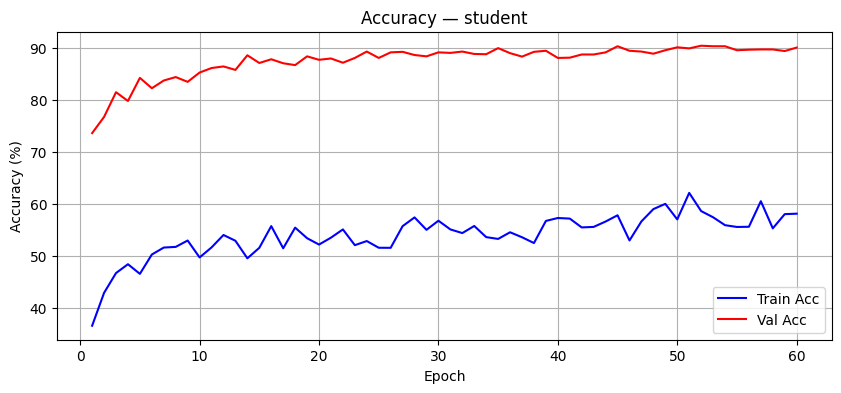

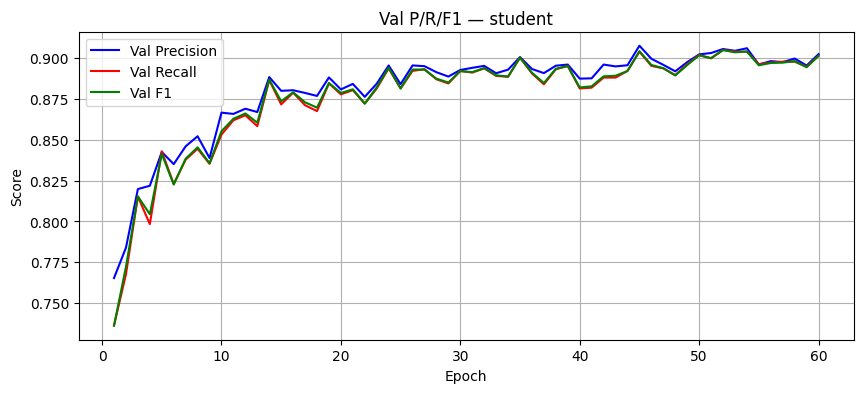

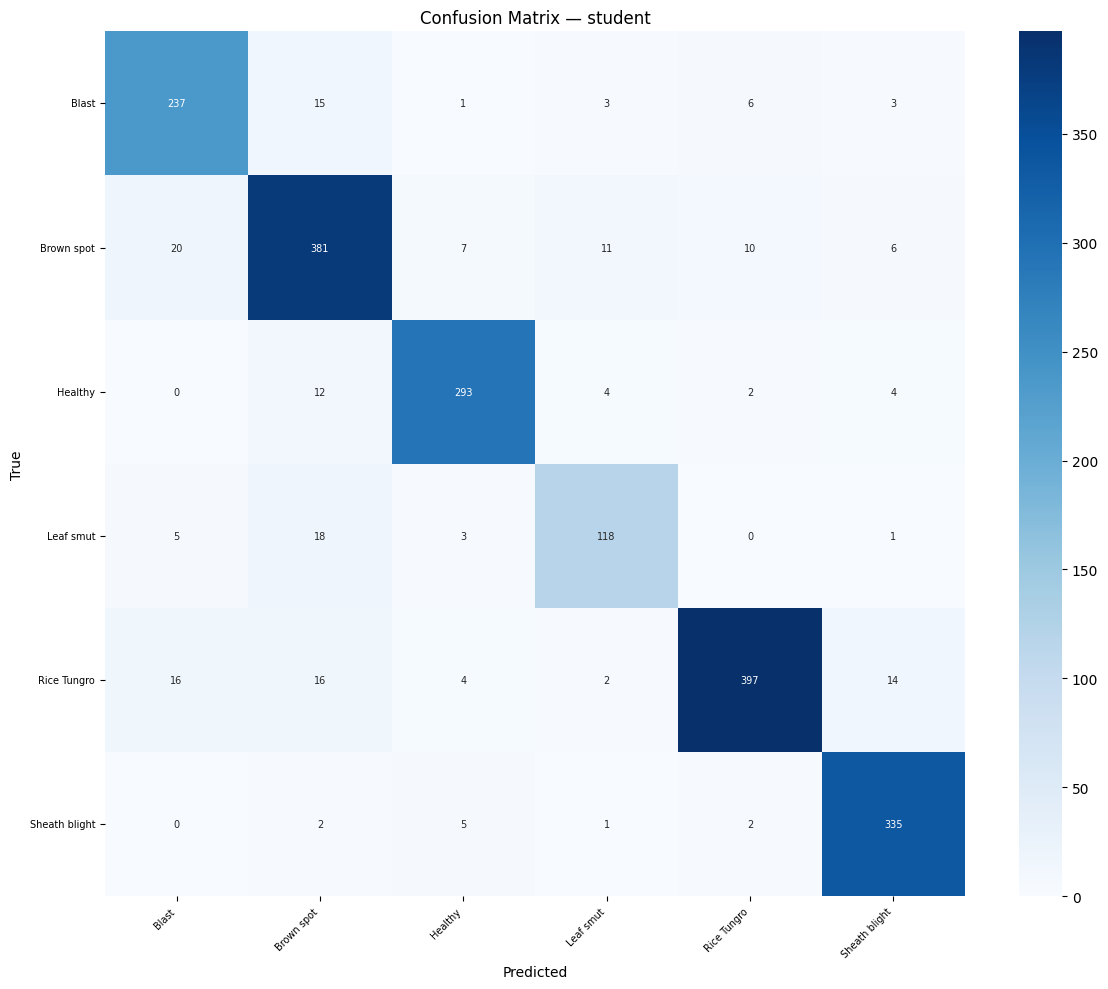

  [Clean FP32] → /content/drive/MyDrive/Research/Model_save/RiceLeafDiseaseBD_CV/clean_student_fp32_fold5.pt  (15.32 MB)
[Fold 5] Student — Acc:90.38%  F1:0.9040

[Fold 5] QAT fine-tuning...


/tmp/ipykernel_922/3063416250.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_922/3063416250.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_922/3063416250.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[QAT] Epoch   1 | T-Loss:1.0003 T-Acc:53.24% | V-Loss:0.5264 V-Acc:90.02%
[QAT] Epoch   2 | T-Loss:0.9636 T-Acc:57.84% | V-Loss:0.5124 V-Acc:90.38%
[QAT] Epoch   3 | T-Loss:1.0031 T-Acc:55.80% | V-Loss:0.5225 V-Acc:90.07%
[QAT] Epoch   4 | T-Loss:0.9838 T-Acc:57.00% | V-Loss:0.5257 V-Acc:90.12%
[QAT] Epoch   5 | T-Loss:0.9934 T-Acc:55.96% | V-Loss:0.5285 V-Acc:89.92%
[QAT] Epoch   6 | T-Loss:0.9734 T-Acc:58.11% | V-Loss:0.5119 V-Acc:90.53%
[QAT] Epoch   7 | T-Loss:0.9743 T-Acc:57.84% | V-Loss:0.4994 V-Acc:90.58%
[QAT] Epoch   8 | T-Loss:1.0090 T-Acc:56.14% | V-Loss:0.5187 V-Acc:90.28%
[QAT] Epoch   9 | T-Loss:0.9747 T-Acc:57.08% | V-Loss:0.5048 V-Acc:90.74%
[QAT] Epoch  10 | T-Loss:0.9629 T-Acc:59.54% | V-Loss:0.5074 V-Acc:90.53%
[QAT] Epoch  11 | T-Loss:0.9665 T-Acc:59.05% | V-Loss:0.5209 V-Acc:90.23%
[QAT] Epoch  12 | T-Loss:0.9681 T-Acc:57.38% | V-Loss:0.5247 V-Acc:90.38%
[QAT] Epoch  13 | T-Loss:0.9582 T-Acc:58.15% | V-Loss:0.4964 V-Acc:90.53%
[QAT] Epoch  14 | T-Loss:0.9983 T-Acc:

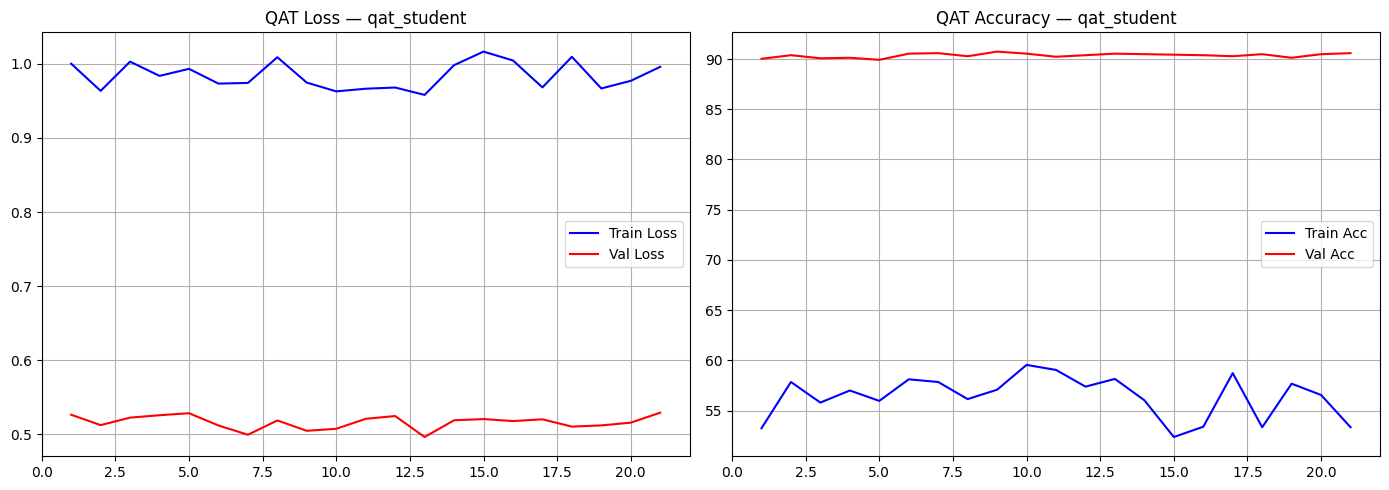

[Fold 5] QAT FP16 — Acc:90.74%  F1:0.9071
Fold 5 complete — results saved.

5-FOLD CV RESULTS — RiceLeafDiseaseBD

  Teacher (ViT-B/16)
    Accuracy : 90.49% ± 0.46%
    Precision: 0.9057 ± 0.0055
    Recall   : 0.9049 ± 0.0046
    F1       : 0.9046 ± 0.0047

  Student FP32 (EffB0)
    Accuracy : 90.58% ± 0.61%
    Precision: 0.9084 ± 0.0048
    Recall   : 0.9058 ± 0.0061
    F1       : 0.9062 ± 0.0057

  QAT FP16  (EffB0)
    Accuracy : 90.64% ± 0.41%
    Precision: 0.9067 ± 0.0037
    Recall   : 0.9064 ± 0.0041
    F1       : 0.9063 ± 0.0041


Per-fold breakdown:
 fold  teacher_acc  teacher_f1  student_acc  student_f1  qat_acc   qat_f1
    1     0.902764    0.902416     0.912487    0.912591 0.908905 0.908779
    2     0.904811    0.904520     0.912999    0.912957 0.911975 0.911808
    3     0.910952    0.911135     0.897134    0.898474 0.900205 0.900214
    4     0.897646    0.897198     0.902764    0.903188 0.903787 0.903472
    5     0.908393    0.907726     0.903787    0.904023 0.

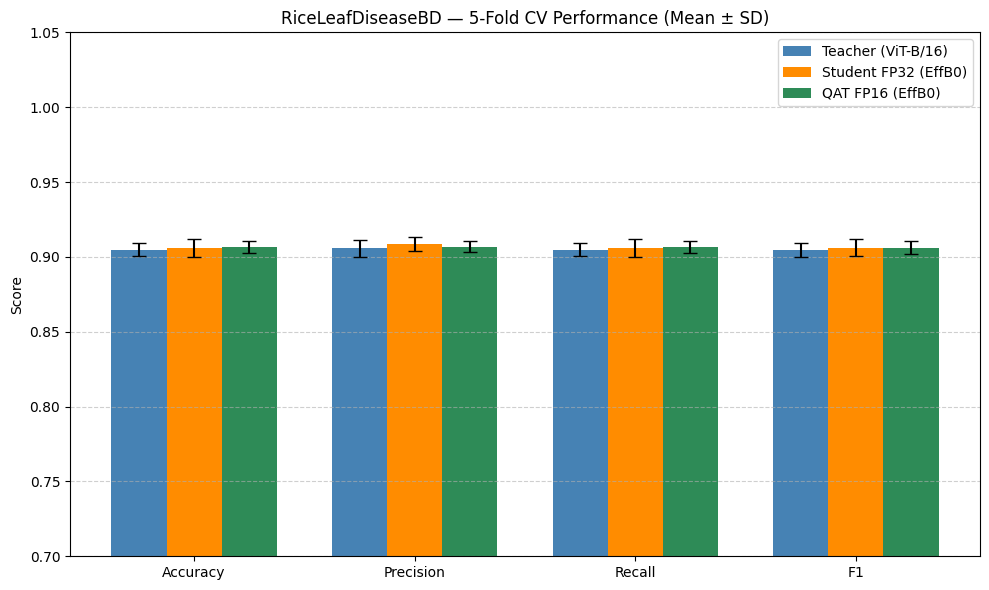

Comparison plot saved to: /content/drive/MyDrive/Research/Model_save/RiceLeafDiseaseBD_CV/cv_comparison_plot.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# 5-FOLD CROSS VALIDATION — Teacher → Student → QAT
# ════════════════════════════════════════════════════════════════════════════════
#
# Key differences vs V7 potato CV:
#   • 6 classes (Blast, Brown spot, Healthy, Leaf smut, Rice Tungro, Sheath blight)
#   • 9,770 images after deduplication (~1,954 per fold val split)
#   • student_lr=3e-4, student_patience=15 (rice-tuned values)
#   • QAT evaluated with use_half=True via evaluate_on_loader (matches rice pipeline)
#   • Class weights recomputed per fold from train split only
#   • Checkpoint/resume: completed folds loaded from fold{n}_results.json
#
from sklearn.model_selection import StratifiedKFold
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import gc

# ── Fold tracking lists ────────────────────────────────────────────────────────
teacher_fold_accs,  teacher_fold_precs,  teacher_fold_recs,  teacher_fold_f1s  = [], [], [], []
student_fold_accs,  student_fold_precs,  student_fold_recs,  student_fold_f1s  = [], [], [], []
qat_fold_accs,      qat_fold_precs,      qat_fold_recs,      qat_fold_f1s      = [], [], [], []
fold_results = []

# ── Checkpoint/resume setup ────────────────────────────────────────────────────
CV_OUTPUT_DIR       = OUTPUT_DIR
completed_folds_path = os.path.join(CV_OUTPUT_DIR, "completed_folds.txt")
completed_folds = []
if os.path.exists(completed_folds_path):
    with open(completed_folds_path, "r") as f:
        completed_folds = [int(x.strip()) for x in f if x.strip()]
    print(f"Resuming — folds already done: {completed_folds}")

# ── Build StratifiedKFold on full dataset ──────────────────────────────────────
# Use a fresh SafeImageFolder with val_test_transform for index/label extraction
index_dataset = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)
all_targets   = [s[1] for s in index_dataset.samples]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG["random_seed"])

# ── Main fold loop ─────────────────────────────────────────────────────────────
for fold, (train_idx, val_idx) in enumerate(skf.split(
        np.arange(len(index_dataset)), all_targets)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold+1}/5  |  train={len(train_idx)}  val={len(val_idx)}")
    print(f"{'='*60}")

    # ── Checkpoint resume ──────────────────────────────────────────────────────
    if (fold + 1) in completed_folds:
        print(f"Fold {fold+1} already completed — loading saved results.")
        fold_json = os.path.join(CV_OUTPUT_DIR, f"fold{fold+1}_results.json")
        if os.path.exists(fold_json):
            with open(fold_json) as fj:
                r = json.load(fj)
            teacher_fold_accs.append(r["teacher_acc"]);  teacher_fold_precs.append(r["teacher_prec"])
            teacher_fold_recs.append(r["teacher_rec"]);  teacher_fold_f1s.append(r["teacher_f1"])
            student_fold_accs.append(r["student_acc"]);  student_fold_precs.append(r["student_prec"])
            student_fold_recs.append(r["student_rec"]);  student_fold_f1s.append(r["student_f1"])
            qat_fold_accs.append(r["qat_acc"]);          qat_fold_precs.append(r["qat_prec"])
            qat_fold_recs.append(r["qat_rec"]);          qat_fold_f1s.append(r["qat_f1"])
            fold_results.append(r)
        continue

    # ── Per-fold DataLoaders ───────────────────────────────────────────────────
    # Train subset: augmented transforms
    # Val   subset: clean val_test_transform
    train_data_fold = SafeImageFolder(CFG["data_dir"], transform=train_transform)
    val_data_fold   = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)

    train_loader_fold = DataLoader(
        Subset(train_data_fold, train_idx),
        batch_size=CFG["batch_size"], shuffle=True,
        num_workers=CFG["num_workers"], pin_memory=True, persistent_workers=True)
    val_loader_fold = DataLoader(
        Subset(val_data_fold, val_idx),
        batch_size=CFG["batch_size"], shuffle=False,
        num_workers=CFG["num_workers"], pin_memory=True, persistent_workers=True)

    # ── Per-fold class weights (train split only) ──────────────────────────────
    train_labels_fold = [all_targets[i] for i in train_idx]
    class_counts_fold = torch.zeros(num_classes)
    for lbl in train_labels_fold:
        class_counts_fold[lbl] += 1
    class_weights_fold = (len(train_labels_fold) /
                          (num_classes * class_counts_fold.clamp(min=1))).to(device)
    print(f"Class weights (min/max): {class_weights_fold.min():.3f} / {class_weights_fold.max():.3f}")

    # ════════════════════════════════════════════════════════
    # STEP 1 — Teacher (ViT-B/16)
    # ════════════════════════════════════════════════════════
    print(f"\n[Fold {fold+1}] Training Teacher...")
    teacher_model = timm.create_model(
        "vit_base_patch16_224", pretrained=True, num_classes=num_classes).to(device)

    param_groups = get_layer_wise_params(
        teacher_model, base_lr=CFG["teacher_base_lr"], decay=CFG["lr_decay"])
    t_optimizer = torch.optim.AdamW(param_groups, weight_decay=CFG["teacher_wd"])

    t_warmup = LinearLR(t_optimizer, start_factor=0.1, end_factor=1.0,
                        total_iters=CFG["teacher_warmup"])
    t_cosine = CosineAnnealingLR(t_optimizer,
                                 T_max=CFG["teacher_epochs"] - CFG["teacher_warmup"],
                                 eta_min=1e-6)
    t_scheduler = SequentialLR(t_optimizer,
                                schedulers=[t_warmup, t_cosine],
                                milestones=[CFG["teacher_warmup"]])

    t_criterion = nn.CrossEntropyLoss(
        label_smoothing=CFG["label_smoothing"], weight=class_weights_fold)

    teacher_ckpt_fold = os.path.join(CV_OUTPUT_DIR, f"best_teacher_fold{fold+1}.pt")
    t_es = EarlyStopping(patience=CFG["teacher_patience"], delta=0.001,
                         verbose=True, path=teacher_ckpt_fold)

    fold_output_dir = CV_OUTPUT_DIR  # plots saved with fold suffix via variant
    teacher_model = train_teacher(
        teacher_model, train_loader_fold, val_loader_fold,
        t_criterion, t_optimizer, t_scheduler,
        CFG["teacher_epochs"], device, t_es, fold_output_dir
    )
    # Rename epoch CSV to fold-specific name
    generic_csv = os.path.join(fold_output_dir, "epoch_summary_teacher.csv")
    if os.path.exists(generic_csv):
        os.rename(generic_csv,
                  os.path.join(fold_output_dir, f"epoch_summary_teacher_fold{fold+1}.csv"))

    # ── Evaluate teacher on val ────────────────────────────────────────────────
    t_acc, t_prec, t_rec, t_f1, _, _ = evaluate_on_loader(
        teacher_model, val_loader_fold, device)
    print(f"[Fold {fold+1}] Teacher — Acc:{t_acc*100:.2f}%  F1:{t_f1:.4f}")

    # ════════════════════════════════════════════════════════
    # STEP 2 — Student (EfficientNet-B0 via KD)
    # ════════════════════════════════════════════════════════
    print(f"\n[Fold {fold+1}] Training Student...")

    # Reload best teacher checkpoint for this fold
    teacher_model_kd = timm.create_model(
        "vit_base_patch16_224", pretrained=False, num_classes=num_classes)
    teacher_model_kd.load_state_dict(
        torch.load(teacher_ckpt_fold, map_location=device, weights_only=True))
    teacher_model_kd = teacher_model_kd.to(device).eval()

    student_model = StudentNet(num_classes=num_classes).to(device)
    s_criterion   = nn.CrossEntropyLoss(
        label_smoothing=CFG["label_smoothing"], weight=class_weights_fold)
    s_optimizer   = torch.optim.AdamW(
        student_model.parameters(),
        lr=CFG["student_lr"], weight_decay=CFG["student_wd"])
    s_scheduler   = CosineAnnealingLR(
        s_optimizer, T_max=CFG["student_epochs"], eta_min=1e-6)

    student_ckpt_fold = os.path.join(CV_OUTPUT_DIR, f"best_student_fold{fold+1}.pt")
    s_es = EarlyStopping(patience=CFG["student_patience"], delta=0.001,
                         verbose=True, path=student_ckpt_fold)

    student_model, _ = train_student(
        student_model, teacher_model_kd,
        train_loader_fold, val_loader_fold,
        s_criterion, s_optimizer, s_scheduler,
        CFG["student_epochs"], device, s_es, fold_output_dir
    )
    generic_csv = os.path.join(fold_output_dir, "epoch_summary_student.csv")
    if os.path.exists(generic_csv):
        os.rename(generic_csv,
                  os.path.join(fold_output_dir, f"epoch_summary_student_fold{fold+1}.csv"))

    # Save clean FP32 student for this fold
    save_clean_student(
        student_model,
        save_path_fp32=os.path.join(CV_OUTPUT_DIR, f"clean_student_fp32_fold{fold+1}.pt"),
        save_path_fp16=None,
        num_classes=num_classes, device=device
    )

    # ── Evaluate student on val ────────────────────────────────────────────────
    s_acc, s_prec, s_rec, s_f1, _, _ = evaluate_on_loader(
        student_model, val_loader_fold, device)
    print(f"[Fold {fold+1}] Student — Acc:{s_acc*100:.2f}%  F1:{s_f1:.4f}")

    # ════════════════════════════════════════════════════════
    # STEP 3 — QAT Fine-tuning (FP16 AMP)
    # ════════════════════════════════════════════════════════
    print(f"\n[Fold {fold+1}] QAT fine-tuning...")

    qat_model, qat_model_fp16, qat_ckpt_fold, _ = train_qat_student(
        student_ckpt_path=student_ckpt_fold,
        teacher_model=teacher_model_kd,
        train_loader=train_loader_fold,
        val_loader=val_loader_fold,
        device=device,
        num_classes=num_classes,
        output_dir=CV_OUTPUT_DIR,
        num_epochs=CFG["qat_epochs"],
        lr=CFG["qat_lr"],
        weight_decay=CFG["qat_wd"],
        patience=CFG["qat_patience"]
    )
    # Rename QAT checkpoint to fold-specific name
    generic_qat = os.path.join(CV_OUTPUT_DIR, "qat_student_best.pth")
    fold_qat    = os.path.join(CV_OUTPUT_DIR, f"qat_student_best_fold{fold+1}.pth")
    if os.path.exists(generic_qat):
        os.rename(generic_qat, fold_qat)

    # ── Evaluate QAT on val ────────────────────────────────────────────────────
    q_acc, q_prec, q_rec, q_f1, _, _ = evaluate_on_loader(
        qat_model_fp16, val_loader_fold, device, use_half=True)
    print(f"[Fold {fold+1}] QAT FP16 — Acc:{q_acc*100:.2f}%  F1:{q_f1:.4f}")

    # ── Accumulate fold metrics ────────────────────────────────────────────────
    teacher_fold_accs.append(t_acc);  teacher_fold_precs.append(t_prec)
    teacher_fold_recs.append(t_rec);  teacher_fold_f1s.append(t_f1)
    student_fold_accs.append(s_acc);  student_fold_precs.append(s_prec)
    student_fold_recs.append(s_rec);  student_fold_f1s.append(s_f1)
    qat_fold_accs.append(q_acc);      qat_fold_precs.append(q_prec)
    qat_fold_recs.append(q_rec);      qat_fold_f1s.append(q_f1)

    fold_result = {
        "fold": fold + 1,
        "teacher_acc": t_acc, "teacher_prec": t_prec,
        "teacher_rec": t_rec, "teacher_f1":   t_f1,
        "student_acc": s_acc, "student_prec": s_prec,
        "student_rec": s_rec, "student_f1":   s_f1,
        "qat_acc":     q_acc, "qat_prec":     q_prec,
        "qat_rec":     q_rec, "qat_f1":       q_f1,
    }
    fold_results.append(fold_result)

    # ── Save fold result + mark complete ──────────────────────────────────────
    with open(os.path.join(CV_OUTPUT_DIR, f"fold{fold+1}_results.json"), "w") as fj:
        json.dump(fold_result, fj)
    with open(completed_folds_path, "a") as fc:
        fc.write(f"{fold+1}\n")
    print(f"Fold {fold+1} complete — results saved.")

    # ── Memory cleanup between folds ──────────────────────────────────────────
    del teacher_model, teacher_model_kd, student_model, qat_model, qat_model_fp16
    del train_loader_fold, val_loader_fold, train_data_fold, val_data_fold
    gc.collect()
    torch.cuda.empty_cache()

# ════════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY — Mean ± Std across 5 folds
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("5-FOLD CV RESULTS — RiceLeafDiseaseBD")
print("="*65)

for model_name, accs, precs, recs, f1s in [
    ("Teacher (ViT-B/16)",     teacher_fold_accs, teacher_fold_precs, teacher_fold_recs, teacher_fold_f1s),
    ("Student FP32 (EffB0)",   student_fold_accs, student_fold_precs, student_fold_recs, student_fold_f1s),
    ("QAT FP16  (EffB0)",      qat_fold_accs,     qat_fold_precs,     qat_fold_recs,     qat_fold_f1s),
]:
    print(f"\n  {model_name}")
    print(f"    Accuracy : {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
    print(f"    Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"    Recall   : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"    F1       : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

print("\n" + "="*65)

# ── Per-fold table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)
print("\nPer-fold breakdown:")
print(results_df[[
    "fold",
    "teacher_acc", "teacher_f1",
    "student_acc", "student_f1",
    "qat_acc",     "qat_f1"
]].to_string(index=False))

csv_out = os.path.join(CV_OUTPUT_DIR, "cv_results_all_folds.csv")
results_df.to_csv(csv_out, index=False)
print(f"\nFull per-fold CSV saved to: {csv_out}")

# ── Grouped bar chart with error bars ─────────────────────────────────────────
metrics      = ["Accuracy", "Precision", "Recall", "F1"]
t_means = [np.mean(teacher_fold_accs), np.mean(teacher_fold_precs),
           np.mean(teacher_fold_recs), np.mean(teacher_fold_f1s)]
t_stds  = [np.std(teacher_fold_accs),  np.std(teacher_fold_precs),
           np.std(teacher_fold_recs),  np.std(teacher_fold_f1s)]
s_means = [np.mean(student_fold_accs), np.mean(student_fold_precs),
           np.mean(student_fold_recs), np.mean(student_fold_f1s)]
s_stds  = [np.std(student_fold_accs),  np.std(student_fold_precs),
           np.std(student_fold_recs),  np.std(student_fold_f1s)]
q_means = [np.mean(qat_fold_accs),     np.mean(qat_fold_precs),
           np.mean(qat_fold_recs),     np.mean(qat_fold_f1s)]
q_stds  = [np.std(qat_fold_accs),      np.std(qat_fold_precs),
           np.std(qat_fold_recs),      np.std(qat_fold_f1s)]

x, w = np.arange(len(metrics)), 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - w, t_means, w, yerr=t_stds, label="Teacher (ViT-B/16)",   color="steelblue",  capsize=5)
plt.bar(x,     s_means, w, yerr=s_stds, label="Student FP32 (EffB0)", color="darkorange",  capsize=5)
plt.bar(x + w, q_means, w, yerr=q_stds, label="QAT FP16 (EffB0)",     color="seagreen",    capsize=5)
plt.xticks(x, metrics)
plt.ylabel("Score"); plt.ylim(0.7, 1.05)
plt.title("RiceLeafDiseaseBD — 5-Fold CV Performance (Mean ± SD)")
plt.legend(); plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plot_path = os.path.join(CV_OUTPUT_DIR, "cv_comparison_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print(f"Comparison plot saved to: {plot_path}")


In [53]:
import numpy as np
import pandas as pd

# ── Per-fold raw results ───────────────────────────────────────────────────────
fold_results = [
    {"fold":1,"teacher_acc":0.902764,"teacher_prec":None,"teacher_rec":None,"teacher_f1":0.902416,
               "student_acc":0.912487,"student_prec":None,"student_rec":None,"student_f1":0.912591,
               "qat_acc":0.908905,   "qat_prec":None,    "qat_rec":None,    "qat_f1":0.908779},
    {"fold":2,"teacher_acc":0.904811,"teacher_prec":None,"teacher_rec":None,"teacher_f1":0.904520,
               "student_acc":0.912999,"student_prec":None,"student_rec":None,"student_f1":0.912957,
               "qat_acc":0.911975,   "qat_prec":None,    "qat_rec":None,    "qat_f1":0.911808},
    {"fold":3,"teacher_acc":0.910952,"teacher_prec":None,"teacher_rec":None,"teacher_f1":0.911135,
               "student_acc":0.897134,"student_prec":None,"student_rec":None,"student_f1":0.898474,
               "qat_acc":0.900205,   "qat_prec":None,    "qat_rec":None,    "qat_f1":0.900214},
    {"fold":4,"teacher_acc":0.897646,"teacher_prec":None,"teacher_rec":None,"teacher_f1":0.897198,
               "student_acc":0.902764,"student_prec":None,"student_rec":None,"student_f1":0.903188,
               "qat_acc":0.903787,   "qat_prec":None,    "qat_rec":None,    "qat_f1":0.903472},
    {"fold":5,"teacher_acc":0.908393,"teacher_prec":None,"teacher_rec":None,"teacher_f1":0.907726,
               "student_acc":0.903787,"student_prec":None,"student_rec":None,"student_f1":0.904023,
               "qat_acc":0.907369,   "qat_prec":None,    "qat_rec":None,    "qat_f1":0.907054},
]

# ── Load full metrics from saved JSONs (prec + rec included) ──────────────────
full_results = []
for fold in range(1, 6):
    json_path = os.path.join(CV_OUTPUT_DIR, f"fold{fold}_results.json")
    if os.path.exists(json_path):
        with open(json_path) as f:
            full_results.append(json.load(f))
        print(f"  Fold {fold}: loaded from JSON ✓")
    else:
        print(f"  Fold {fold}: JSON not found — using acc/f1 only")
        full_results.append(fold_results[fold-1])

# ── Aggregate ─────────────────────────────────────────────────────────────────
def agg(key):
    vals = [r[key] for r in full_results if r.get(key) is not None]
    return np.mean(vals), np.std(vals)

print("\n" + "="*70)
print("5-FOLD CV — RiceLeafDiseaseBD — FULL RESULTS")
print("="*70)

for model, prefix in [
    ("Teacher  (ViT-B/16)    ", "teacher"),
    ("Student  FP32 (EffB0)  ", "student"),
    ("QAT FP16 (EffB0)       ", "qat"),
]:
    acc_m,  acc_s  = agg(f"{prefix}_acc")
    prec_m, prec_s = agg(f"{prefix}_prec")
    rec_m,  rec_s  = agg(f"{prefix}_rec")
    f1_m,   f1_s   = agg(f"{prefix}_f1")
    print(f"\n  {model}")
    print(f"    Accuracy  : {acc_m*100:.2f}% ± {acc_s*100:.2f}%")
    print(f"    Precision : {prec_m:.4f}  ± {prec_s:.4f}")
    print(f"    Recall    : {rec_m:.4f}  ± {rec_s:.4f}")
    print(f"    F1        : {f1_m:.4f}  ± {f1_s:.4f}")

print("\n" + "="*70)

# ── Per-fold table ─────────────────────────────────────────────────────────────
df = pd.DataFrame(full_results)
cols = ["fold",
        "teacher_acc","teacher_prec","teacher_rec","teacher_f1",
        "student_acc","student_prec","student_rec","student_f1",
        "qat_acc",    "qat_prec",    "qat_rec",    "qat_f1"]
cols_present = [c for c in cols if c in df.columns]
print("\nPer-fold full breakdown:")
print(df[cols_present].to_string(index=False))

# ── Save complete CSV ──────────────────────────────────────────────────────────
csv_out = os.path.join(CV_OUTPUT_DIR, "cv_full_results.csv")
df[cols_present].to_csv(csv_out, index=False)
print(f"\nSaved to: {csv_out}")

  Fold 1: loaded from JSON ✓
  Fold 2: loaded from JSON ✓
  Fold 3: loaded from JSON ✓
  Fold 4: loaded from JSON ✓
  Fold 5: loaded from JSON ✓

5-FOLD CV — RiceLeafDiseaseBD — FULL RESULTS

  Teacher  (ViT-B/16)    
    Accuracy  : 90.49% ± 0.46%
    Precision : 0.9057  ± 0.0055
    Recall    : 0.9049  ± 0.0046
    F1        : 0.9046  ± 0.0047

  Student  FP32 (EffB0)  
    Accuracy  : 90.58% ± 0.61%
    Precision : 0.9084  ± 0.0048
    Recall    : 0.9058  ± 0.0061
    F1        : 0.9062  ± 0.0057

  QAT FP16 (EffB0)       
    Accuracy  : 90.64% ± 0.41%
    Precision : 0.9067  ± 0.0037
    Recall    : 0.9064  ± 0.0041
    F1        : 0.9063  ± 0.0041


Per-fold full breakdown:
 fold  teacher_acc  teacher_prec  teacher_rec  teacher_f1  student_acc  student_prec  student_rec  student_f1  qat_acc  qat_prec  qat_rec   qat_f1
    1     0.902764      0.903061     0.902764    0.902416     0.912487      0.913025     0.912487    0.912591 0.908905  0.909106 0.908905 0.908779
    2     0.90481

In [54]:
import os
import copy
import torch
import torch.nn as nn
from torchvision import models

# ── Parameter & Size Helpers ──────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def deployed_params(student_net_model):
    """Excludes feature_adapter — not present in deployed model."""
    return sum(p.numel() for n, p in student_net_model.named_parameters()
               if p.requires_grad and not n.startswith('feature_adapter'))

def file_size_mb(path):
    if os.path.exists(path):
        return os.path.getsize(path) / (1024 * 1024)
    return None

# ── Load last fold's models for param counting ────────────────────────────────
# Use fold 5 checkpoints (any fold gives same architecture/param count)
last_fold = 5

teacher_ckpt_last  = os.path.join(CV_OUTPUT_DIR, f"best_teacher_fold{last_fold}.pt")
student_ckpt_last  = os.path.join(CV_OUTPUT_DIR, f"best_student_fold{last_fold}.pt")
qat_ckpt_last      = os.path.join(CV_OUTPUT_DIR, f"qat_student_best_fold{last_fold}.pth")
clean_fp32_last    = os.path.join(CV_OUTPUT_DIR, f"clean_student_fp32_fold{last_fold}.pt")
clean_fp16_last    = os.path.join(CV_OUTPUT_DIR, f"qat_clean_fp16.pt")  # last fold's QAT clean

# Teacher
teacher_count = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=num_classes)
teacher_params_m = count_params(teacher_count) / 1e6
teacher_size_mb  = file_size_mb(teacher_ckpt_last)
del teacher_count

# Student (full, with feature_adapter)
student_count = StudentNet(num_classes=num_classes)
student_params_total_m   = count_params(student_count) / 1e6
student_params_deploy_m  = deployed_params(student_count) / 1e6
student_fp32_mb_deploy   = student_params_deploy_m * 4        # estimated deployed size
student_fp32_mb_ckpt     = file_size_mb(student_ckpt_last)    # checkpoint (includes adapter)
clean_fp32_mb            = file_size_mb(clean_fp32_last)
del student_count

# QAT FP16 deployed
student_fp16_mb_deploy   = student_params_deploy_m * 2
clean_fp16_mb            = file_size_mb(clean_fp16_last)

flops_m = 413.9  # EfficientNet-B0 FLOPs (same as V7)

# ── Latency — measure on val_loader_fold (rebuild fold 5 loader) ──────────────
import time

def measure_latency(model, loader, n_warmup=10, n_runs=50, use_half=False):
    model.eval().to(device)
    if use_half:
        model = model.half()
    images, _ = next(iter(loader))
    images = images.to(device)
    if use_half:
        images = images.half()
    for _ in range(n_warmup):
        _ = model(images)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_runs):
        _ = model(images)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / n_runs / images.size(0) * 1000

# Rebuild a val loader for latency measurement (fold 5 val indices)
skf_temp  = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG["random_seed"])
fold_splits = list(skf_temp.split(np.arange(len(index_dataset)), all_targets))
_, val_idx_last = fold_splits[last_fold - 1]

val_data_lat  = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)
val_loader_lat = DataLoader(
    Subset(val_data_lat, val_idx_last),
    batch_size=CFG["batch_size"], shuffle=False,
    num_workers=2, pin_memory=True)

# Load models for latency
teacher_lat = timm.create_model(
    "vit_base_patch16_224", pretrained=False, num_classes=num_classes)
teacher_lat.load_state_dict(
    torch.load(teacher_ckpt_last, map_location=device, weights_only=True))
teacher_lat = teacher_lat.to(device).eval()

student_lat = StudentNet(num_classes=num_classes)
student_lat.load_state_dict(
    torch.load(student_ckpt_last, map_location=device, weights_only=True))
student_lat = student_lat.to(device).eval()

qat_lat = StudentNet(num_classes=num_classes)
qat_lat.load_state_dict(
    torch.load(qat_ckpt_last, map_location=device, weights_only=True))
qat_lat = qat_lat.to(device).eval()

print("Measuring latency (~30 seconds)...")
lat_teacher = measure_latency(teacher_lat, val_loader_lat)
lat_student = measure_latency(student_lat, val_loader_lat)
lat_qat     = measure_latency(qat_lat,     val_loader_lat, use_half=True)

del teacher_lat, student_lat, qat_lat
torch.cuda.empty_cache()

# ── Mean CV metrics (from earlier cell) ───────────────────────────────────────
t_acc_m  = np.mean(teacher_fold_accs)
t_prec_m = np.mean([r["teacher_prec"] for r in full_results if r.get("teacher_prec")])
t_rec_m  = np.mean([r["teacher_rec"]  for r in full_results if r.get("teacher_rec")])
t_f1_m   = np.mean(teacher_fold_f1s)

s_acc_m  = np.mean(student_fold_accs)
s_prec_m = np.mean([r["student_prec"] for r in full_results if r.get("student_prec")])
s_rec_m  = np.mean([r["student_rec"]  for r in full_results if r.get("student_rec")])
s_f1_m   = np.mean(student_fold_f1s)

q_acc_m  = np.mean(qat_fold_accs)
q_prec_m = np.mean([r["qat_prec"] for r in full_results if r.get("qat_prec")])
q_rec_m  = np.mean([r["qat_rec"]  for r in full_results if r.get("qat_rec")])
q_f1_m   = np.mean(qat_fold_f1s)

# ── Final Table — mirrors V7 exactly ──────────────────────────────────────────
print("\n" + "="*115)
header = (f"{'Model':<22} | {'Acc':>7} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | "
          f"{'Params':>8} | {'Size (deploy)':>13} | {'FLOPs':>8} | {'Latency ms/img':>14}")
print(header)
print("-"*115)
print(f"{'Teacher (ViT-B/16)':<22} | {t_acc_m*100:>6.2f}% | {t_prec_m:>6.4f} | {t_rec_m:>6.4f} | {t_f1_m:>6.4f} | "
      f"{teacher_params_m:>7.1f}M | {'~330 MB':>13} | {'—':>8} | {lat_teacher:>13.2f}")
print(f"{'FP32 Student (EffB0)':<22} | {s_acc_m*100:>6.2f}% | {s_prec_m:>6.4f} | {s_rec_m:>6.4f} | {s_f1_m:>6.4f} | "
      f"{student_params_deploy_m:>7.2f}M | {student_fp32_mb_deploy:>10.2f} MB | {flops_m:>6.1f}M | {lat_student:>13.2f}")
print(f"{'FP16 QAT (EffB0)':<22} | {q_acc_m*100:>6.2f}% | {q_prec_m:>6.4f} | {q_rec_m:>6.4f} | {q_f1_m:>6.4f} | "
      f"{student_params_deploy_m:>7.2f}M | {student_fp16_mb_deploy:>10.2f} MB | {flops_m:>6.1f}M | {lat_qat:>13.2f}")
print("="*115)

# ── Checkpoint sizes (includes feature_adapter) ────────────────────────────────
print(f"\nCheckpoint file sizes (include training-only feature_adapter "
      f"+{(student_params_total_m - student_params_deploy_m):.2f}M params):")
print(f"  Teacher checkpoint (fold {last_fold}) : "
      f"{teacher_size_mb:.2f} MB  ({teacher_params_m:.1f}M params)")
print(f"  Student FP32 checkpoint              : "
      f"{student_fp32_mb_ckpt:.2f} MB  ({student_params_total_m:.2f}M params total)")
print(f"  Clean FP32 deployed                  : "
      f"{clean_fp32_mb:.2f} MB  ({student_params_deploy_m:.2f}M params)"
      if clean_fp32_mb else f"  Clean FP32 deployed                  : {student_fp32_mb_deploy:.2f} MB (estimated)")
print(f"  Clean FP16 deployed                  : "
      f"{clean_fp16_mb:.2f} MB  ({student_params_deploy_m:.2f}M params)"
      if clean_fp16_mb else f"  Clean FP16 deployed                  : {student_fp16_mb_deploy:.2f} MB (estimated)")

# ── Speedup & compression ──────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Teacher  latency       : {lat_teacher:.2f} ms/img")
print(f"  Student FP32 latency   : {lat_student:.2f} ms/img  →  {lat_teacher/lat_student:.1f}× faster")
print(f"  QAT FP16 latency       : {lat_qat:.2f} ms/img  →  {lat_teacher/lat_qat:.1f}× faster")
print(f"  Size reduction FP32    : {330/student_fp32_mb_deploy:.0f}× smaller than teacher")
print(f"  Size reduction FP16    : {330/student_fp16_mb_deploy:.0f}× smaller than teacher")
print(f"  Acc drop Teacher→FP32  : {(t_acc_m - s_acc_m)*100:.2f}%")
print(f"  Acc drop Teacher→QAT   : {(t_acc_m - q_acc_m)*100:.2f}%")
print(f"  Acc change FP32→QAT    : {(q_acc_m - s_acc_m)*100:+.2f}%")
print(f"{'='*50}")

# ── Save final CSV ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {"Model": "Teacher (ViT-B/16)",
     "Acc_%": t_acc_m*100, "Precision": t_prec_m, "Recall": t_rec_m, "F1": t_f1_m,
     "Params_M": teacher_params_m, "Size_MB": 330,
     "FLOPs_M": None, "Latency_ms": lat_teacher},
    {"Model": "FP32 Student (EffB0)",
     "Acc_%": s_acc_m*100, "Precision": s_prec_m, "Recall": s_rec_m, "F1": s_f1_m,
     "Params_M": student_params_deploy_m, "Size_MB": student_fp32_mb_deploy,
     "FLOPs_M": flops_m, "Latency_ms": lat_student},
    {"Model": "FP16 QAT (EffB0)",
     "Acc_%": q_acc_m*100, "Precision": q_prec_m, "Recall": q_rec_m, "F1": q_f1_m,
     "Params_M": student_params_deploy_m, "Size_MB": student_fp16_mb_deploy,
     "FLOPs_M": flops_m, "Latency_ms": lat_qat},
])
csv_out = os.path.join(CV_OUTPUT_DIR, "cv_final_summary.csv")
summary_df.to_csv(csv_out, index=False)
print(f"\nFinal summary saved to: {csv_out}")

Measuring latency (~30 seconds)...

Model                  |     Acc |   Prec |    Rec |     F1 |   Params | Size (deploy) |    FLOPs | Latency ms/img
-------------------------------------------------------------------------------------------------------------------
Teacher (ViT-B/16)     |  90.49% | 0.9057 | 0.9049 | 0.9046 |    85.8M |       ~330 MB |        — |          4.87
FP32 Student (EffB0)   |  90.58% | 0.9084 | 0.9058 | 0.9062 |    4.02M |      16.06 MB |  413.9M |          0.81
FP16 QAT (EffB0)       |  90.64% | 0.9067 | 0.9064 | 0.9063 |    4.02M |       8.03 MB |  413.9M |          0.47

Checkpoint file sizes (include training-only feature_adapter +0.98M params):
  Teacher checkpoint (fold 5) : 327.37 MB  (85.8M params)
  Student FP32 checkpoint              : 19.36 MB  (5.00M params total)
  Clean FP32 deployed                  : 15.61 MB  (4.02M params)
  Clean FP16 deployed                  : 7.86 MB  (4.02M params)

  Teacher  latency       : 4.87 ms/img
  Student FP32